In [2]:
import pandas as pd


In [3]:
df = pd.read_excel(r'C:\Users\trodr\Documents\proyecto-torax-v2.0\01-dataset\resultados\resultados_torax_1.xlsx')

In [7]:
import pandas as pd
import numpy as np

# Ya tienes cargado: df = pd.read_excel(...)

# ============================================================
# ANÁLISIS DE DELTAS ΔAUC (CONSOLA)
# ============================================================

# 1. CREAR TABLA PIVOTE (AUC por Modelo, Etiqueta y Condición)
pivot_auc = df.pivot_table(
    index=['Modelo', 'Etiqueta'],
    columns='Condición',
    values='AUC',
    aggfunc='first'
)

# 2. CALCULAR DELTAS (vs sin_procesar baseline)
pivot_auc['Δ eliminar_texto'] = pivot_auc['eliminar_texto'] - pivot_auc['sin_procesar']
pivot_auc['Δ crop_pulmones'] = pivot_auc['crop_pulmones'] - pivot_auc['sin_procesar']

# 3. IDENTIFICAR MEJOR CONDICIÓN Y SU DELTA
def get_best_condition(row):
    max_auc = row[['sin_procesar', 'eliminar_texto', 'crop_pulmones']].max()
    best = row[['sin_procesar', 'eliminar_texto', 'crop_pulmones']].idxmax()
    delta = max_auc - row['sin_procesar']
    return best, delta

pivot_auc[['Mejor_condición', 'Δ_máximo']] = pivot_auc[['sin_procesar', 'eliminar_texto', 'crop_pulmones']].apply(
    lambda row: pd.Series(get_best_condition(row)), axis=1
)

# 4. RESETEAR ÍNDICE
resultado = pivot_auc.reset_index()

# 5. MOSTRAR TABLA COMPLETA
print("="*120)
print("TABLA COMPLETA CON DELTAS ΔAUC")
print("="*120)
print(resultado[['Modelo', 'Etiqueta', 'sin_procesar', 'eliminar_texto', 'Δ eliminar_texto', 
                  'crop_pulmones', 'Δ crop_pulmones', 'Mejor_condición', 'Δ_máximo']].to_string(index=False))
print()

# 6. PROMEDIOS POR MODELO
print("="*120)
print("PROMEDIOS DE DELTAS POR MODELO")
print("="*120)
for modelo in resultado['Modelo'].unique():
    datos_modelo = resultado[resultado['Modelo'] == modelo]
    promedio_et = datos_modelo['Δ eliminar_texto'].mean()
    promedio_crop = datos_modelo['Δ crop_pulmones'].mean()
    max_crop = datos_modelo['Δ crop_pulmones'].max()
    min_crop = datos_modelo['Δ crop_pulmones'].min()
    
    print(f"\n{modelo}:")
    print(f"  Δ promedio eliminar_texto: {promedio_et:+.4f} ({promedio_et*100:+.2f}pp)")
    print(f"  Δ promedio crop_pulmones:  {promedio_crop:+.4f} ({promedio_crop*100:+.2f}pp)")
    print(f"  Δ máximo (crop):           {max_crop:+.4f} ({max_crop*100:+.2f}pp)")
    print(f"  Δ mínimo (crop):           {min_crop:+.4f} ({min_crop*100:+.2f}pp)")

# 7. ESTADÍSTICAS GLOBALES
print("\n" + "="*120)
print("ESTADÍSTICAS GLOBALES")
print("="*120)
print("\nImpacto de eliminar_texto:")
print(f"  Máximo aumento:      {resultado['Δ eliminar_texto'].max():+.4f} ({resultado['Δ eliminar_texto'].max()*100:+.2f}pp)")
print(f"  Máxima disminución:  {resultado['Δ eliminar_texto'].min():+.4f} ({resultado['Δ eliminar_texto'].min()*100:+.2f}pp)")
print(f"  Promedio general:    {resultado['Δ eliminar_texto'].mean():+.4f} ({resultado['Δ eliminar_texto'].mean()*100:+.2f}pp)")

print("\nImpacto de crop_pulmones:")
print(f"  Máximo aumento:      {resultado['Δ crop_pulmones'].max():+.4f} ({resultado['Δ crop_pulmones'].max()*100:+.2f}pp)")
print(f"  Máxima disminución:  {resultado['Δ crop_pulmones'].min():+.4f} ({resultado['Δ crop_pulmones'].min()*100:+.2f}pp)")
print(f"  Promedio general:    {resultado['Δ crop_pulmones'].mean():+.4f} ({resultado['Δ crop_pulmones'].mean()*100:+.2f}pp)")

# 8. TOP 5 MÁS BENEFICIADOS POR CROP
print("\n" + "="*120)
print("TOP 5: MÁS BENEFICIADOS POR CROP_PULMONES")
print("="*120)
top_crop = resultado.nlargest(5, 'Δ crop_pulmones')[['Modelo', 'Etiqueta', 'sin_procesar', 'crop_pulmones', 'Δ crop_pulmones']]
print(top_crop.to_string(index=False))

# 9. TOP 5 MÁS PERJUDICADOS POR CROP
print("\n" + "="*120)
print("TOP 5: MÁS PERJUDICADOS POR CROP_PULMONES")
print("="*120)
bottom_crop = resultado.nsmallest(5, 'Δ crop_pulmones')[['Modelo', 'Etiqueta', 'sin_procesar', 'crop_pulmones', 'Δ crop_pulmones']]
print(bottom_crop.to_string(index=False))

# 10. ANÁLISIS POR LABEL (cómo responde cada pathología en los 3 modelos)
print("\n" + "="*120)
print("ANÁLISIS POR LABEL: COMPORTAMIENTO EN TODOS LOS MODELOS (CROP_PULMONES)")
print("="*120)
for etiqueta in resultado['Etiqueta'].unique():
    datos_label = resultado[resultado['Etiqueta'] == etiqueta]
    print(f"\n{etiqueta}:")
    for idx, row in datos_label.iterrows():
        print(f"  {row['Modelo']:15} | sin_procesar: {row['sin_procesar']:.4f} → crop: {row['crop_pulmones']:.4f} | Δ: {row['Δ crop_pulmones']:+.4f}")

print("\n" + "="*120)

TABLA COMPLETA CON DELTAS ΔAUC
      Modelo                   Etiqueta  sin_procesar  eliminar_texto  Δ eliminar_texto  crop_pulmones  Δ crop_pulmones Mejor_condición  Δ_máximo
  CNN Simple                Atelectasis        0.6430          0.6368           -0.0062         0.6451           0.0021   crop_pulmones    0.0021
  CNN Simple               Cardiomegaly        0.6480          0.6486            0.0006         0.6655           0.0175   crop_pulmones    0.0175
  CNN Simple              Consolidation        0.6741          0.6723           -0.0018         0.5840          -0.0901    sin_procesar    0.0000
  CNN Simple                      Edema        0.7303          0.7074           -0.0229         0.7143          -0.0160    sin_procesar    0.0000
  CNN Simple Enlarged Cardiomediastinum        0.5877          0.5443           -0.0434         0.5979           0.0102   crop_pulmones    0.0102
  CNN Simple                   Fracture        0.5428          0.5559            0.0131      

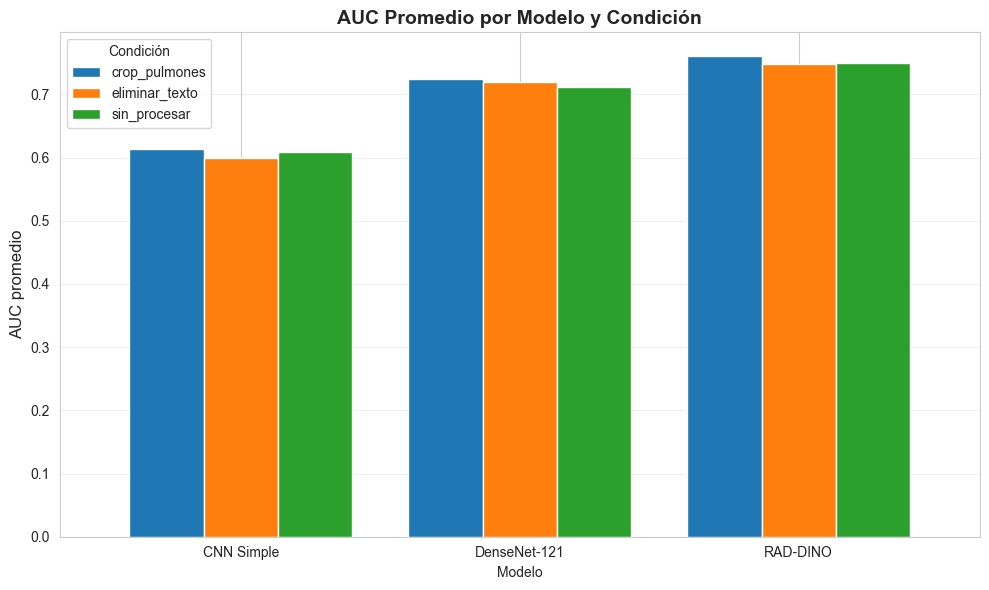

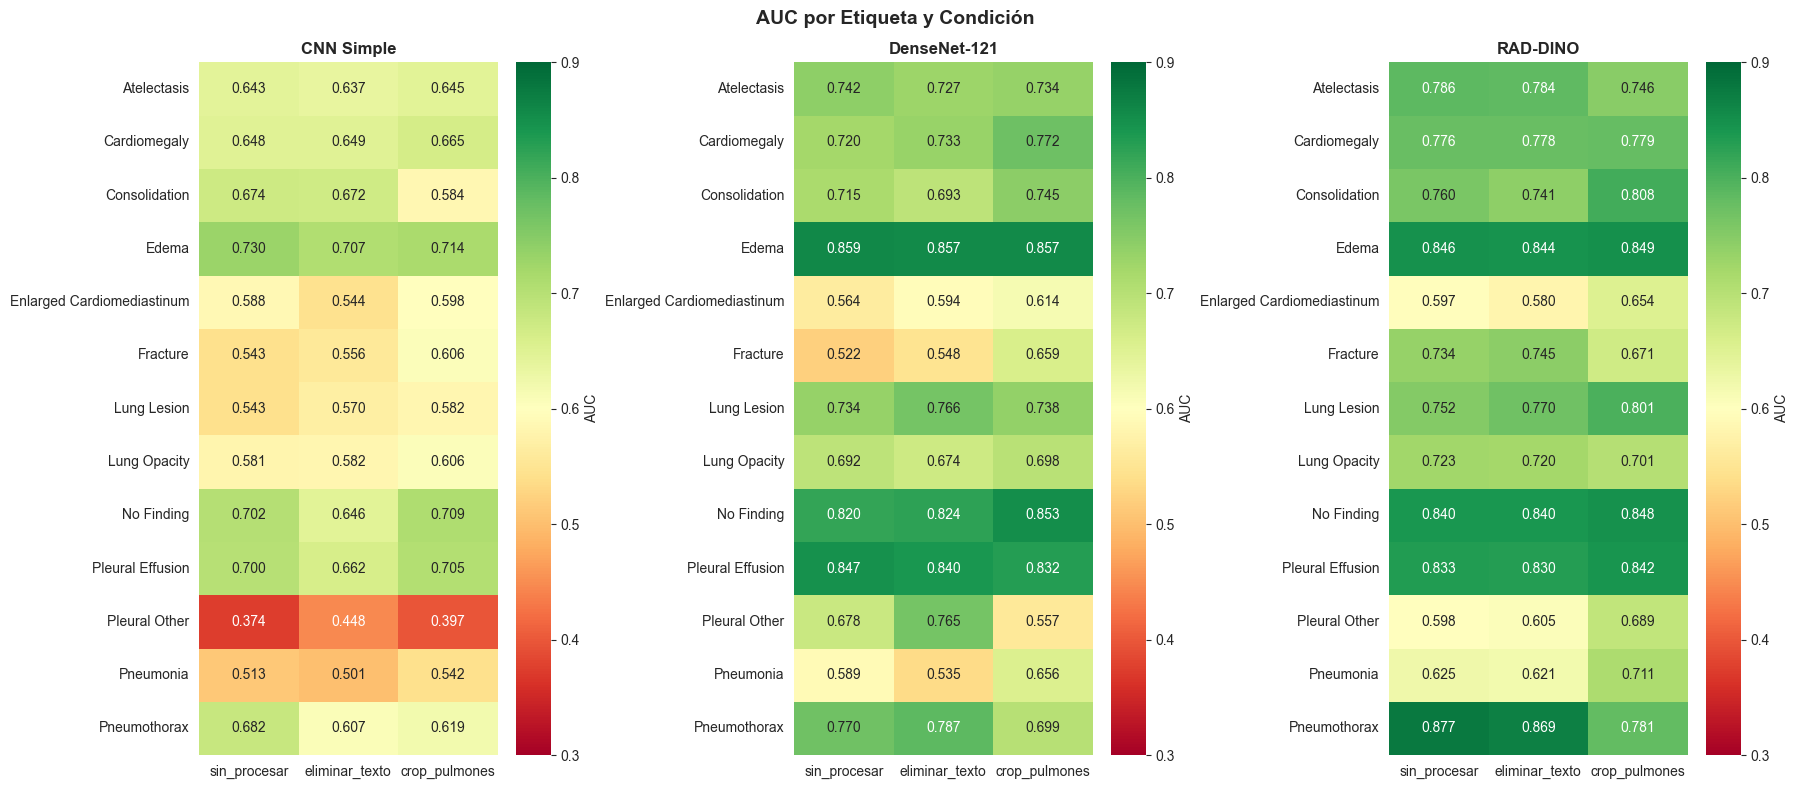

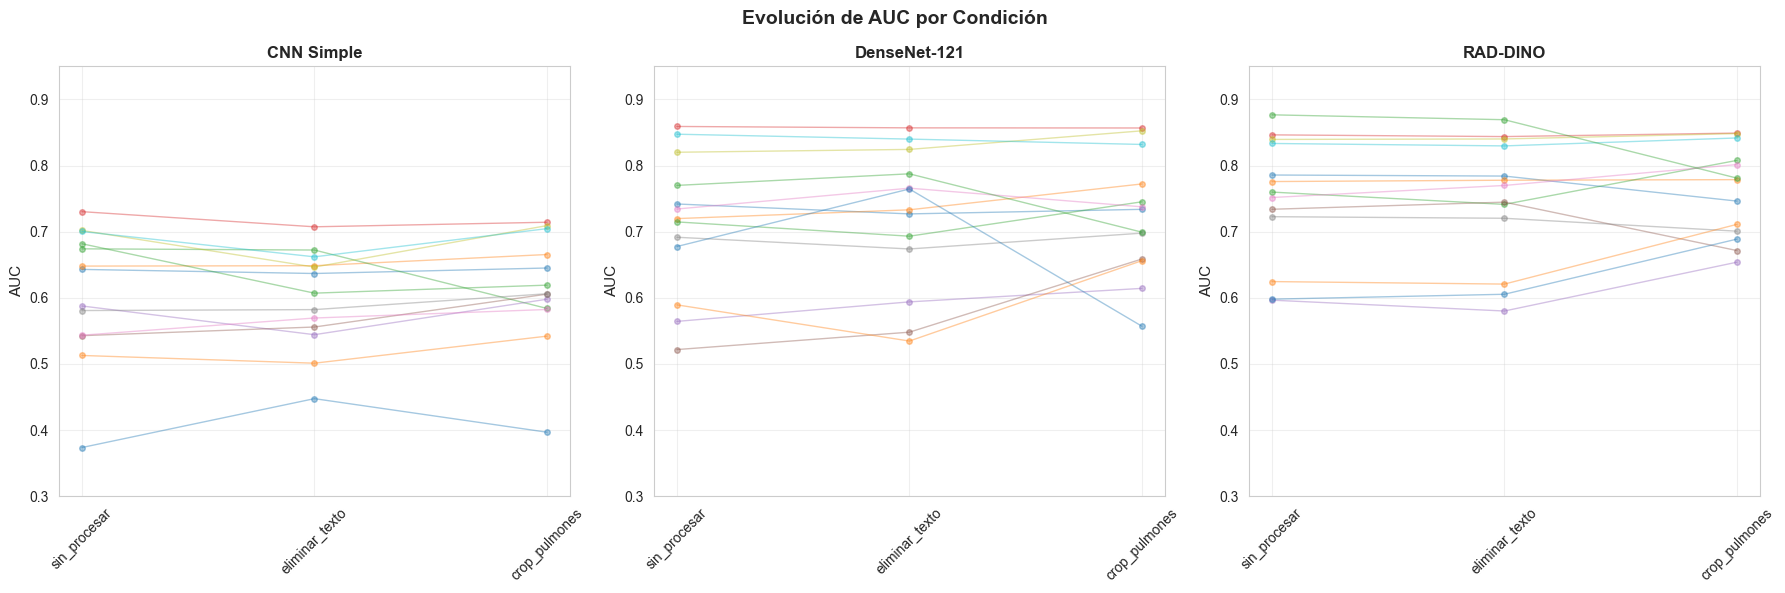

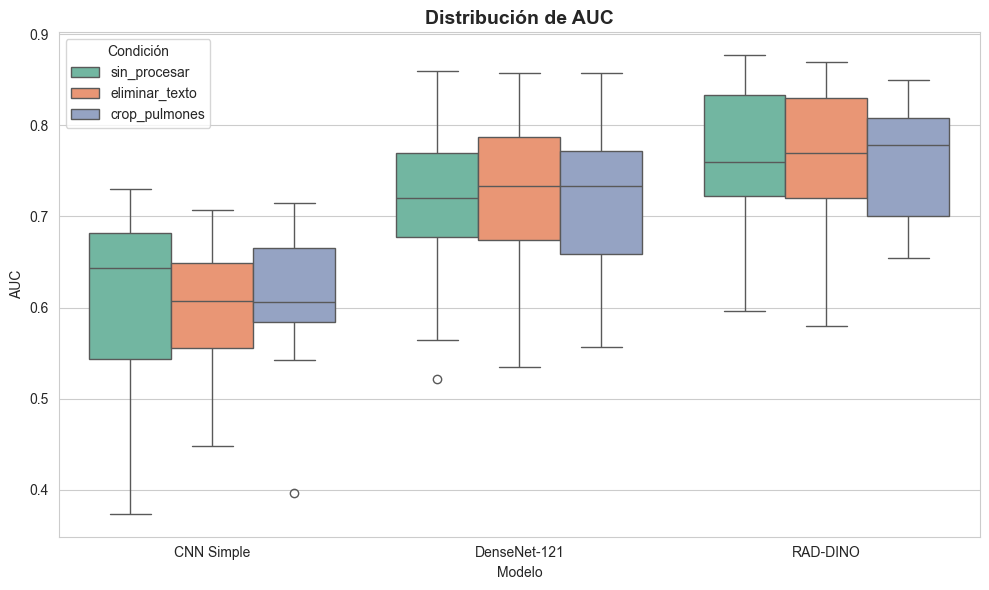

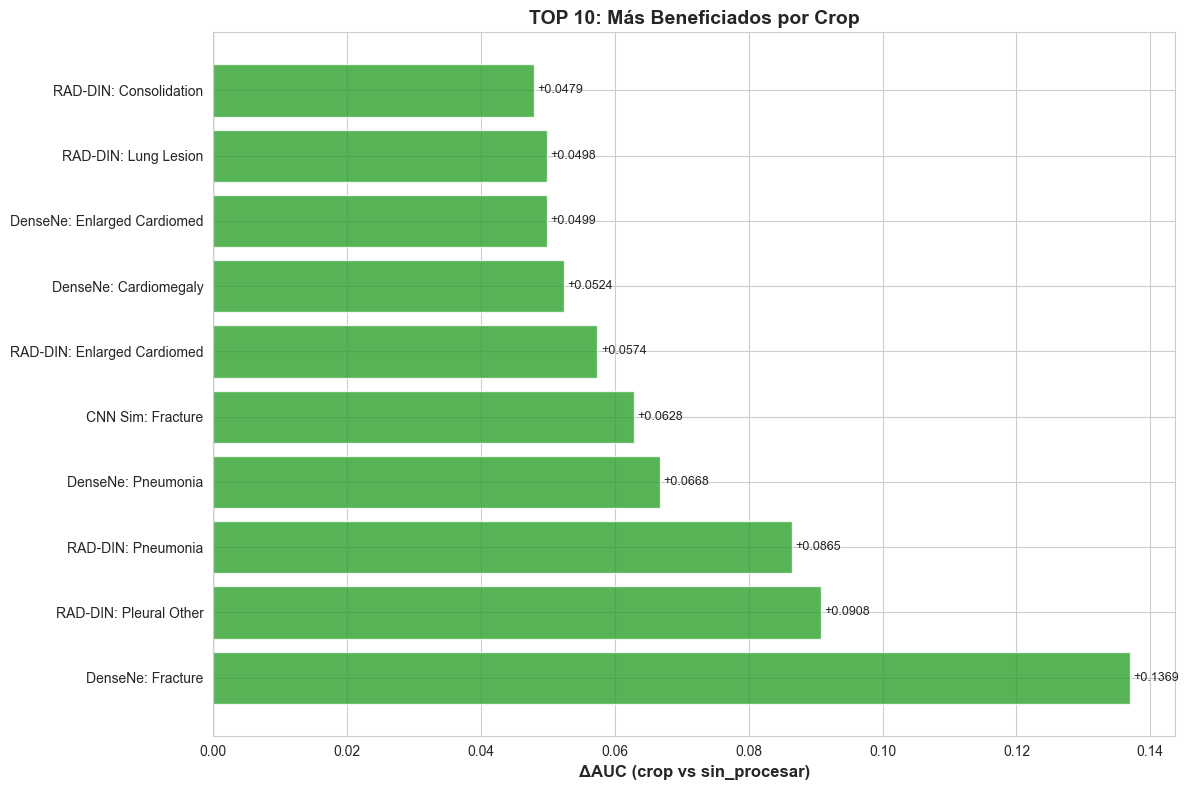

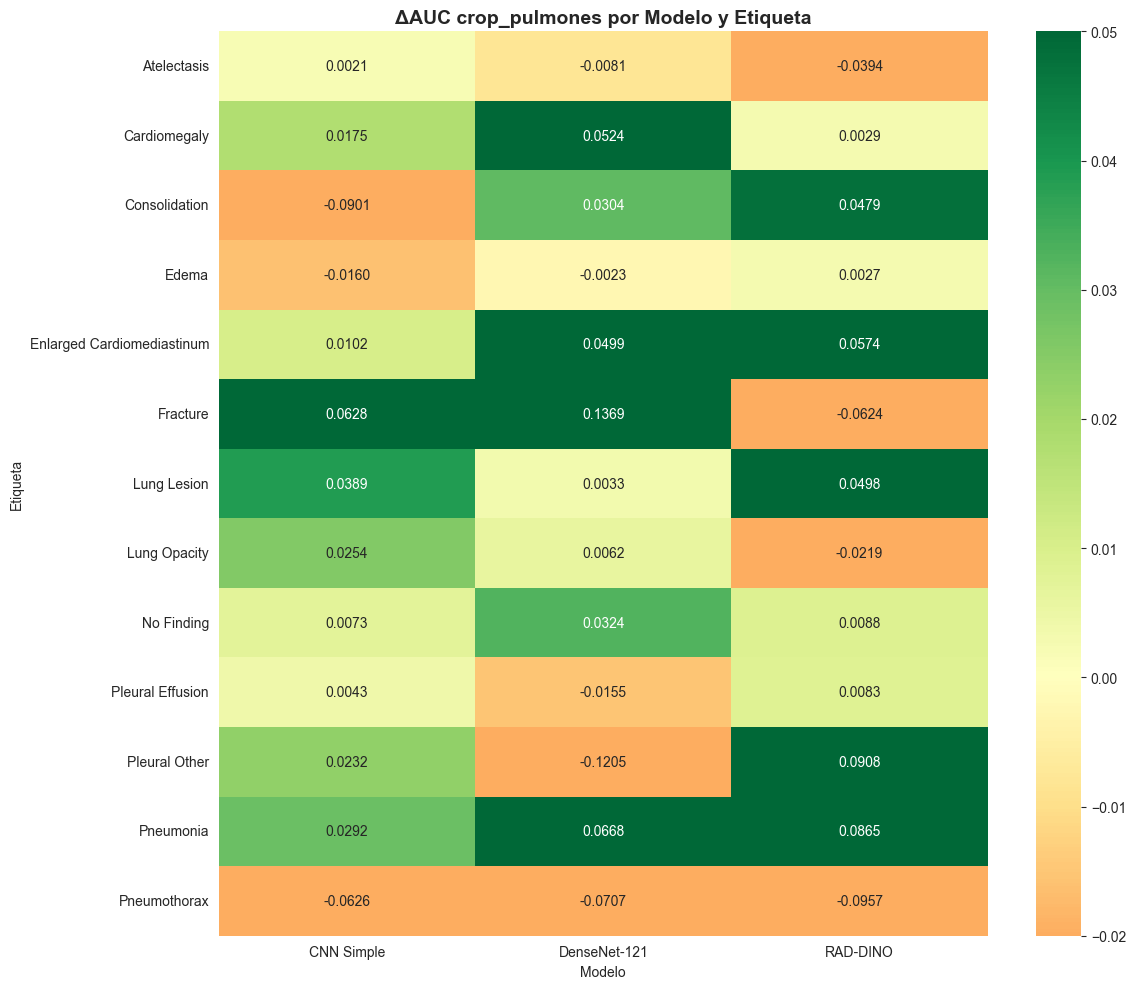

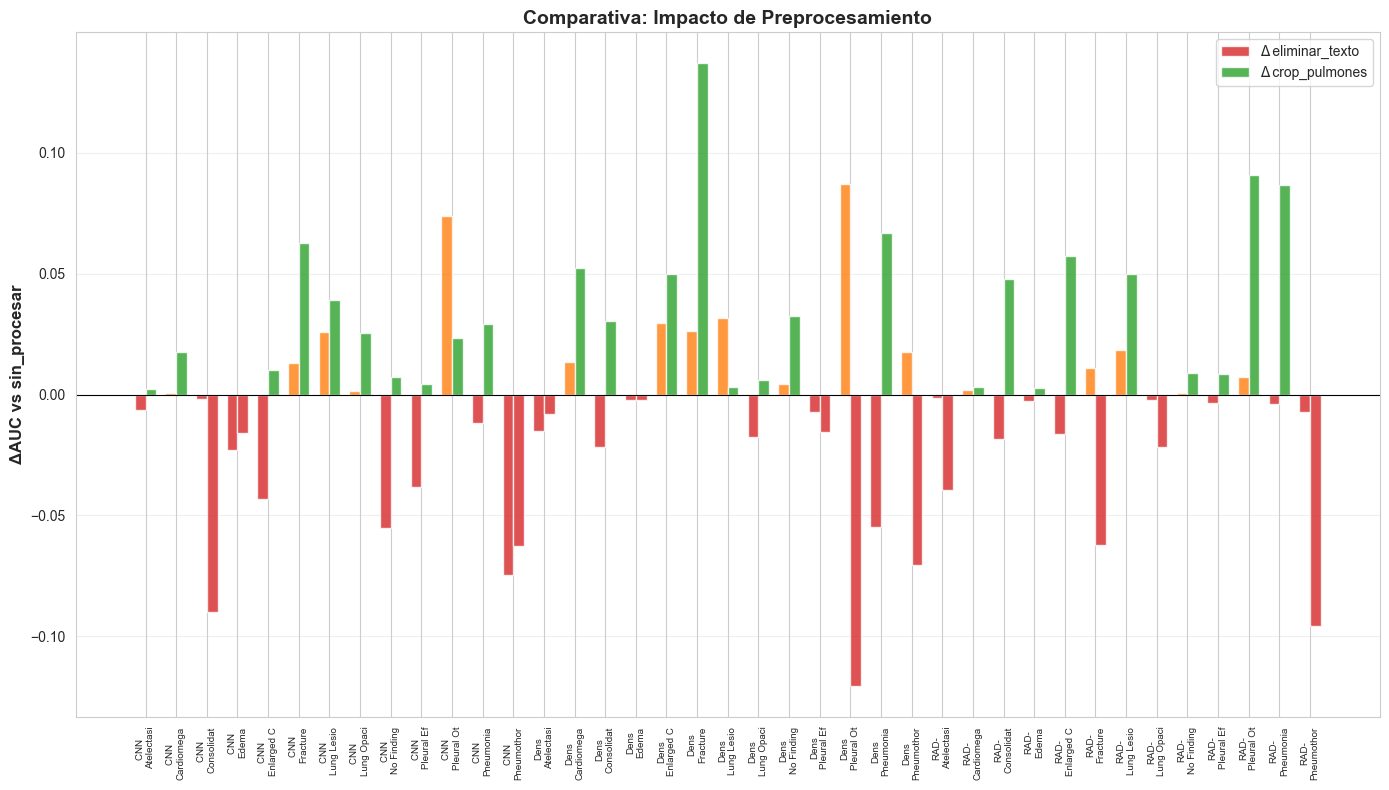


✅ TODAS LAS VISUALIZACIONES COMPLETADAS


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# PREPARAR DATOS
pivot_auc = df.pivot_table(
    index=['Modelo', 'Etiqueta'], 
    columns='Condición', 
    values='AUC', 
    aggfunc='first'
)
pivot_auc['Δ eliminar_texto'] = pivot_auc['eliminar_texto'] - pivot_auc['sin_procesar']
pivot_auc['Δ crop_pulmones'] = pivot_auc['crop_pulmones'] - pivot_auc['sin_procesar']
resultado = pivot_auc.reset_index()

# === GRÁFICO 1 ===
fig, ax = plt.subplots(figsize=(10, 6))
promedio = df.groupby(['Modelo', 'Condición'])['AUC'].mean().unstack()
promedio.plot(kind='bar', ax=ax, width=0.8, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_title('AUC Promedio por Modelo y Condición', fontsize=14, fontweight='bold')
ax.set_ylabel('AUC promedio', fontsize=12)
ax.legend(title='Condición')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# === GRÁFICO 2 ===
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
for idx, modelo in enumerate(['CNN Simple', 'DenseNet-121', 'RAD-DINO']):
    datos_modelo = resultado[resultado['Modelo'] == modelo].set_index('Etiqueta')
    matrix_data = datos_modelo[['sin_procesar', 'eliminar_texto', 'crop_pulmones']].values
    sns.heatmap(matrix_data, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.3, vmax=0.9,
                xticklabels=['sin_procesar', 'eliminar_texto', 'crop_pulmones'], 
                yticklabels=datos_modelo.index, ax=axes[idx], cbar_kws={'label': 'AUC'})
    axes[idx].set_title(f'{modelo}', fontsize=12, fontweight='bold')
plt.suptitle('AUC por Etiqueta y Condición', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# === GRÁFICO 3 ===
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
condiciones = ['sin_procesar', 'eliminar_texto', 'crop_pulmones']
for idx, modelo in enumerate(['CNN Simple', 'DenseNet-121', 'RAD-DINO']):
    for _, fila in resultado[resultado['Modelo'] == modelo].iterrows():
        valores = [fila['sin_procesar'], fila['eliminar_texto'], fila['crop_pulmones']]
        axes[idx].plot(condiciones, valores, marker='o', alpha=0.4, linewidth=1, markersize=4)
    axes[idx].set_title(f'{modelo}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('AUC', fontsize=11)
    axes[idx].set_ylim(0.3, 0.95)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)
plt.suptitle('Evolución de AUC por Condición', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# === GRÁFICO 4 ===
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='Modelo', y='AUC', hue='Condición', ax=ax, palette='Set2')
ax.set_title('Distribución de AUC', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# === GRÁFICO 5 ===
fig, ax = plt.subplots(figsize=(12, 8))
top_10 = resultado.nlargest(10, 'Δ crop_pulmones').copy()
top_10['Label'] = top_10['Modelo'].str[:7] + ': ' + top_10['Etiqueta'].str[:18]
colors = ['#2ca02c' if x > 0 else '#d62728' for x in top_10['Δ crop_pulmones']]
ax.barh(range(len(top_10)), top_10['Δ crop_pulmones'].values, color=colors, alpha=0.8)
ax.set_yticks(range(len(top_10)))
ax.set_yticklabels(top_10['Label'].values)
ax.set_xlabel('ΔAUC (crop vs sin_procesar)', fontsize=12, fontweight='bold')
ax.set_title('TOP 10: Más Beneficiados por Crop', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
for i, v in enumerate(top_10['Δ crop_pulmones'].values):
    ax.text(v + 0.0005, i, f'{v:+.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# === GRÁFICO 6 ===
fig, ax = plt.subplots(figsize=(12, 10))
heatmap_data = resultado.pivot_table(index='Etiqueta', columns='Modelo', values='Δ crop_pulmones')
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='RdYlGn', center=0, ax=ax, vmin=-0.02, vmax=0.05)
ax.set_title('ΔAUC crop_pulmones por Modelo y Etiqueta', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# === GRÁFICO 7 ===
fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(resultado))
width = 0.35
ax.bar(x - width/2, resultado['Δ eliminar_texto'], width, label='Δ eliminar_texto', 
       color=['#ff7f0e' if v >= 0 else '#d62728' for v in resultado['Δ eliminar_texto']], alpha=0.8)
ax.bar(x + width/2, resultado['Δ crop_pulmones'], width, label='Δ crop_pulmones',
       color=['#2ca02c' if v >= 0 else '#d62728' for v in resultado['Δ crop_pulmones']], alpha=0.8)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_ylabel('ΔAUC vs sin_procesar', fontsize=12, fontweight='bold')
ax.set_title('Comparativa: Impacto de Preprocesamiento', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"{r['Modelo'][:4]}\n{r['Etiqueta'][:10]}" for _, r in resultado.iterrows()], rotation=90, fontsize=7)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ TODAS LAS VISUALIZACIONES COMPLETADAS")

VISUALIZACIONES DE TODAS LAS MÉTRICAS - PROYECTO TÓRAX
Modelos: 3
Etiquetas: 13
Condiciones: 3
Total filas: 117

[1/10] Box Plot...


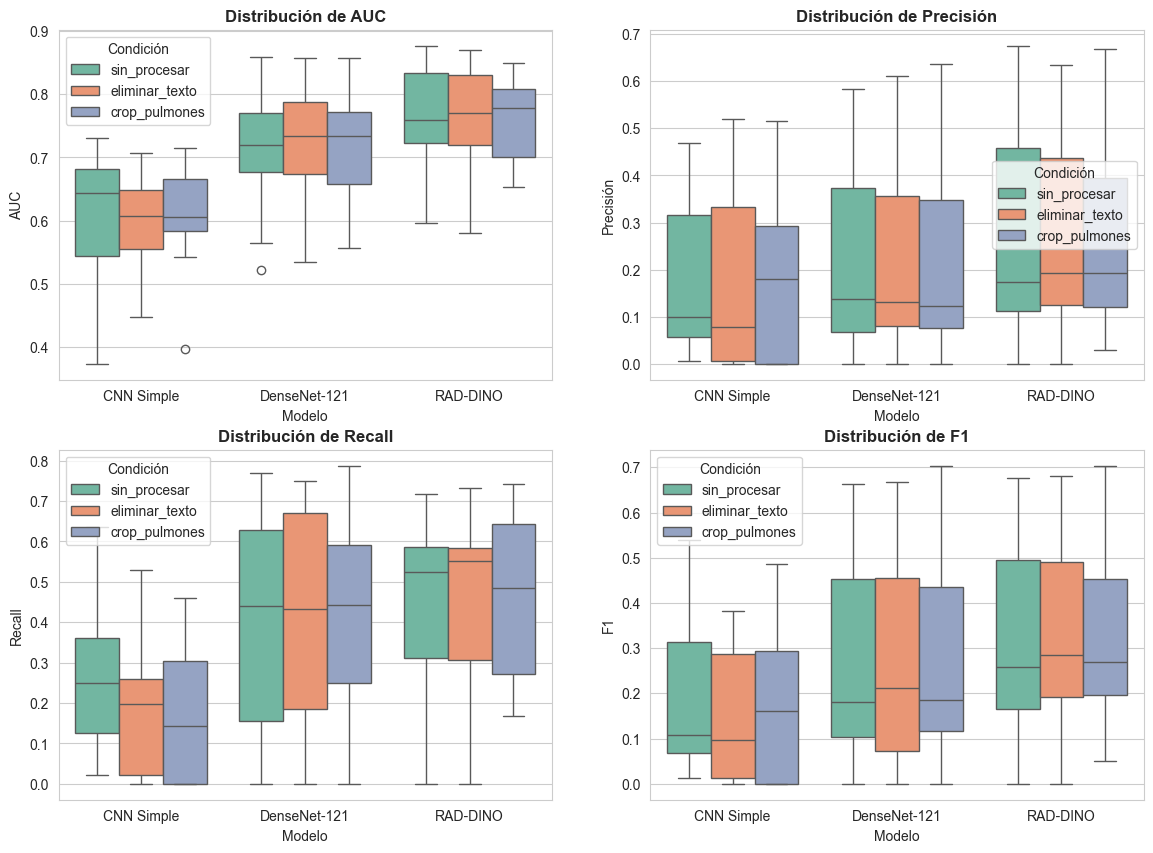

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import pi

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# df = pd.read_excel(r'C:\Users\trodr\Documents\proyecto-torax-v2.0\01-dataset\resultados\resultados_torax_1.xlsx')

print("="*80)
print("VISUALIZACIONES DE TODAS LAS MÉTRICAS - PROYECTO TÓRAX")
print("="*80)
print(f"Modelos: {df['Modelo'].nunique()}")
print(f"Etiquetas: {df['Etiqueta'].nunique()}")
print(f"Condiciones: {df['Condición'].nunique()}")
print(f"Total filas: {len(df)}\n")

# ============================================================
# VISUALIZACIÓN 1: BOX PLOT
# ============================================================
print("[1/10] Box Plot...")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, metrica in enumerate(['AUC', 'Precisión', 'Recall', 'F1']):
    sns.boxplot(data=df, x='Modelo', y=metrica, hue='Condición', ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'Distribución de {metrica}', fontsize=12, fontweight='bold')

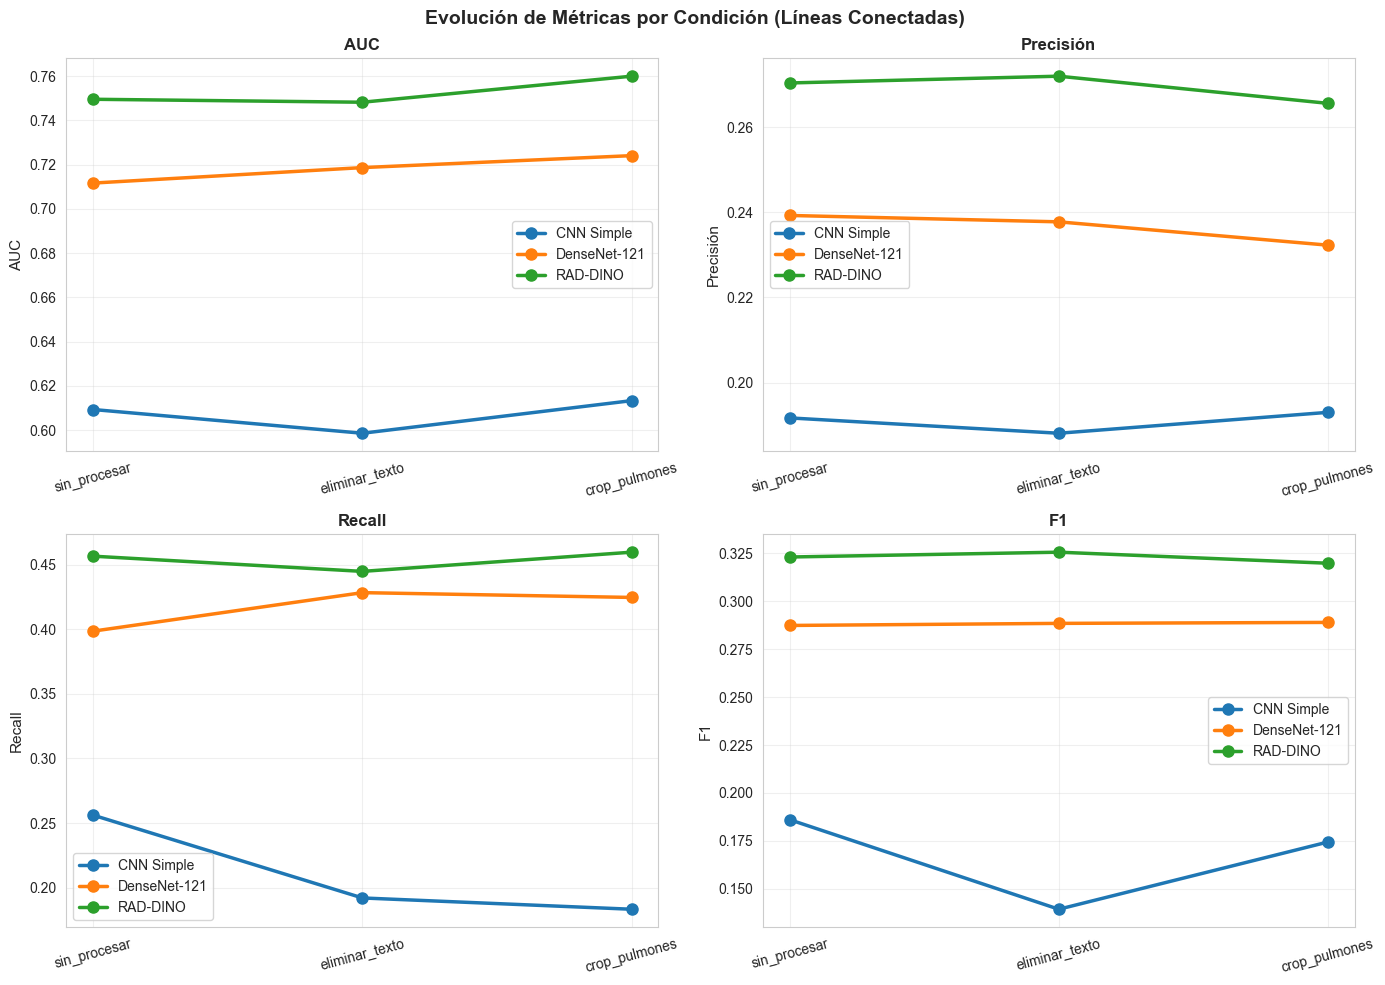

In [12]:
# ALTERNATIVA 1: LÍNEAS CONECTADAS POR MÉTRICA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
condiciones = ['sin_procesar', 'eliminar_texto', 'crop_pulmones']
colores = {'CNN Simple': '#1f77b4', 'DenseNet-121': '#ff7f0e', 'RAD-DINO': '#2ca02c'}

for idx, metrica in enumerate(['AUC', 'Precisión', 'Recall', 'F1']):
    for modelo in df['Modelo'].unique():
        datos_modelo = df[df['Modelo'] == modelo]
        valores = [datos_modelo[datos_modelo['Condición'] == c][metrica].mean() for c in condiciones]
        axes[idx].plot(condiciones, valores, marker='o', linewidth=2.5, markersize=8, 
                      label=modelo, color=colores.get(modelo, '#333'))
    
    axes[idx].set_title(f'{metrica}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(metrica, fontsize=11)
    axes[idx].set_xlabel('')
    axes[idx].legend(fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=15)

plt.suptitle('Evolución de Métricas por Condición (Líneas Conectadas)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

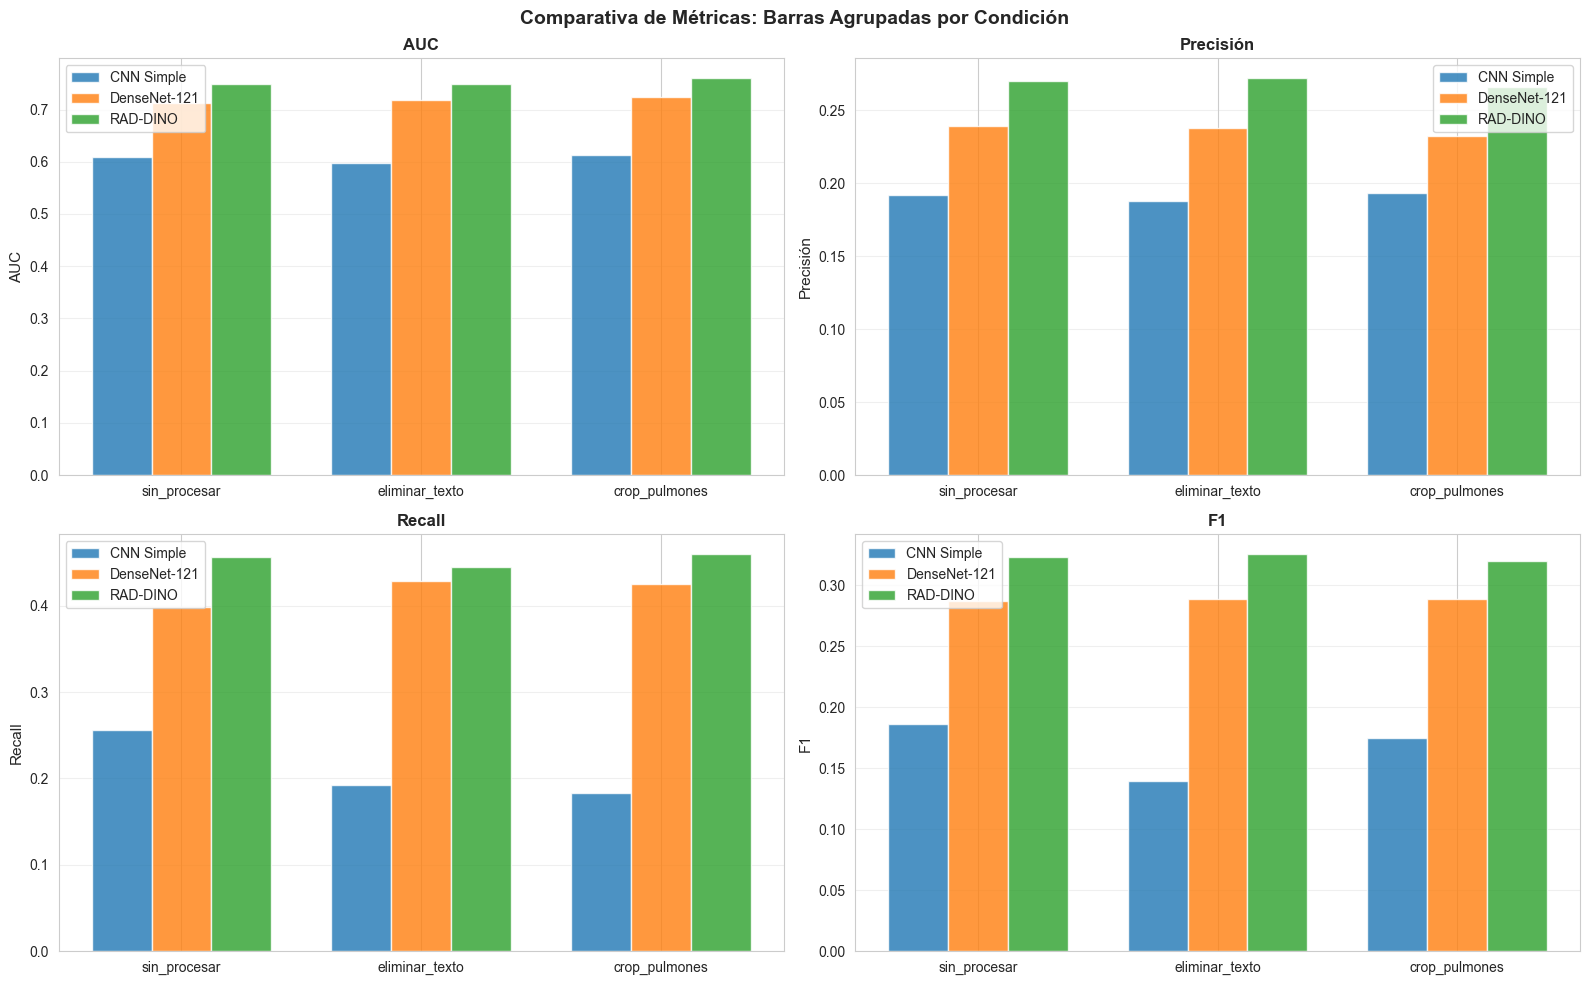

In [13]:
# ALTERNATIVA 2: BARRAS AGRUPADAS
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
condiciones = ['sin_procesar', 'eliminar_texto', 'crop_pulmones']
x_pos = np.arange(len(condiciones))
width = 0.25

for idx, metrica in enumerate(['AUC', 'Precisión', 'Recall', 'F1']):
    modelos = df['Modelo'].unique()
    
    for i, modelo in enumerate(modelos):
        datos_modelo = df[df['Modelo'] == modelo]
        valores = [datos_modelo[datos_modelo['Condición'] == c][metrica].mean() for c in condiciones]
        axes[idx].bar(x_pos + i*width, valores, width, label=modelo, alpha=0.8)
    
    axes[idx].set_title(f'{metrica}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(metrica, fontsize=11)
    axes[idx].set_xticks(x_pos + width)
    axes[idx].set_xticklabels(condiciones, fontsize=10)
    axes[idx].legend(fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Comparativa de Métricas: Barras Agrupadas por Condición', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

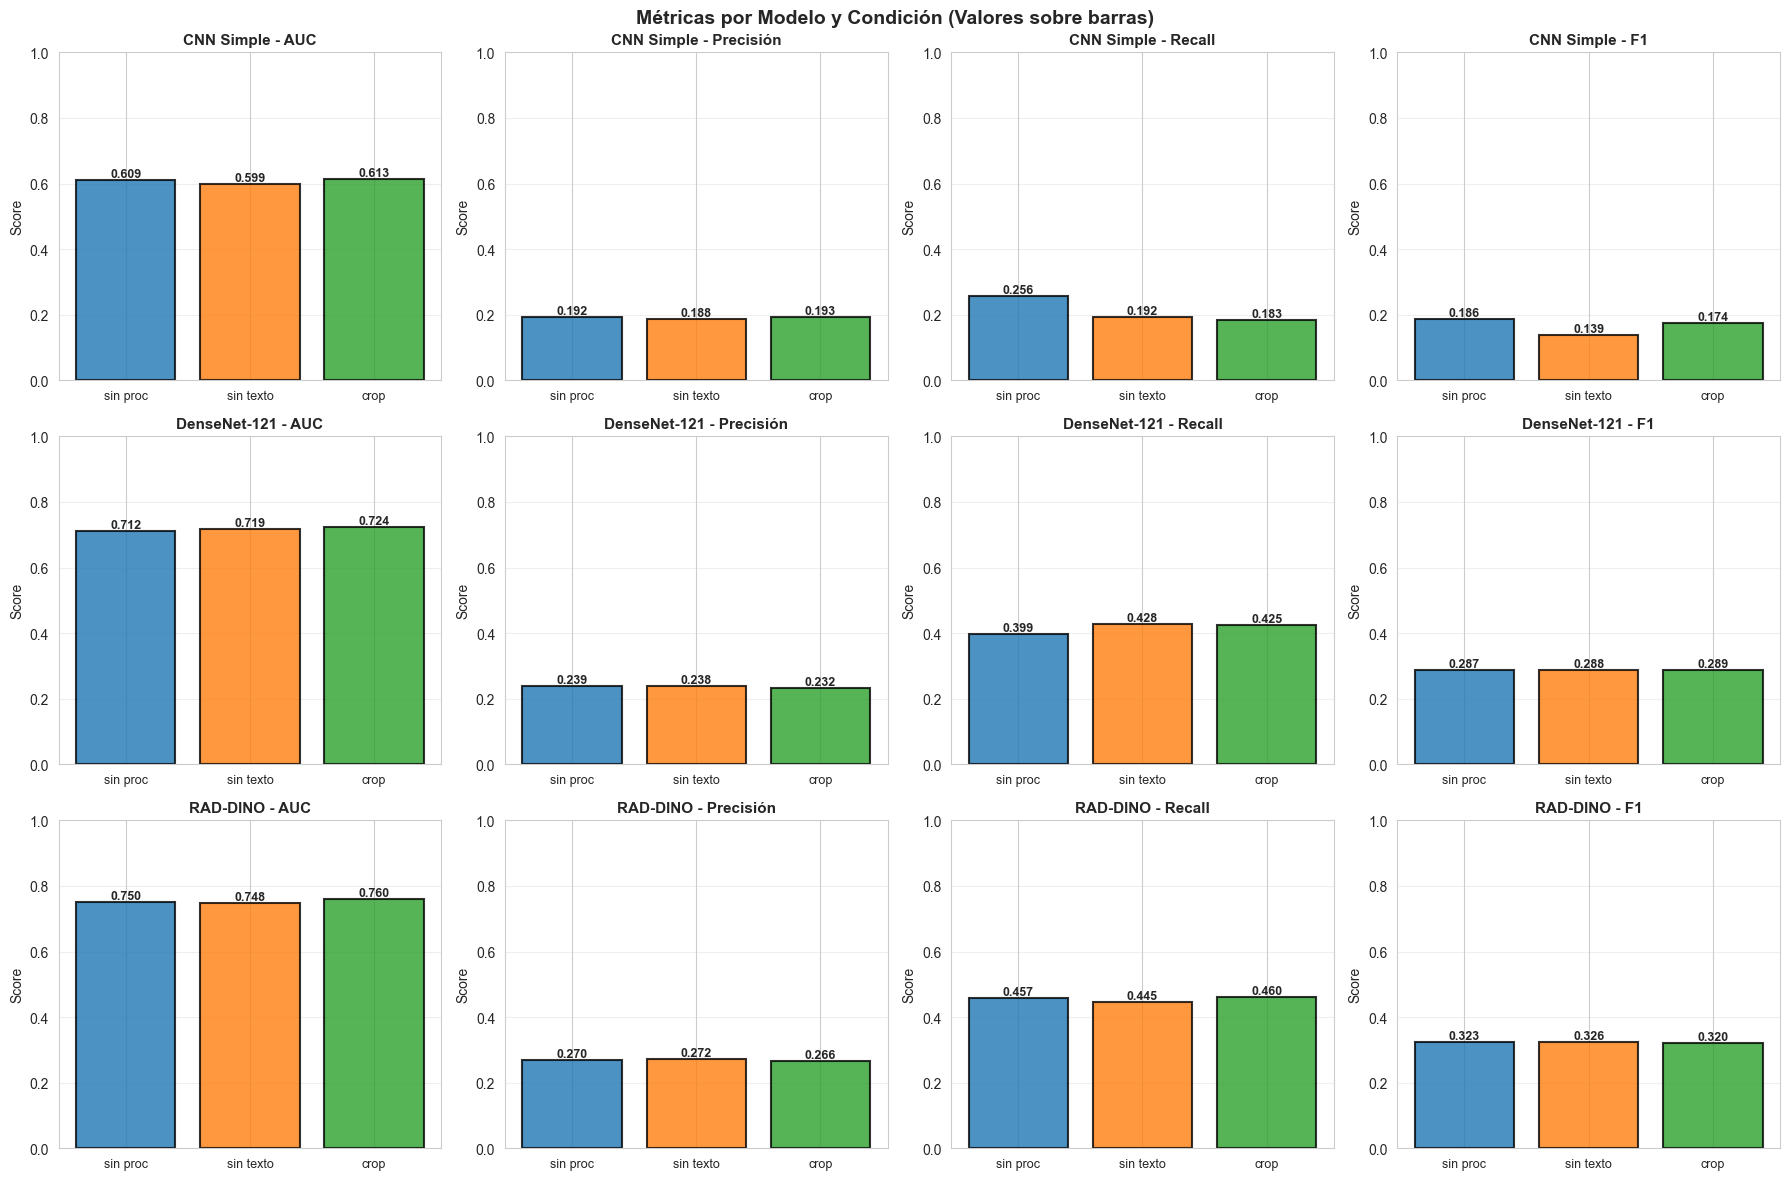

In [14]:
# ALTERNATIVA 3: FACETED - UN MODELO POR ROW
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
condiciones = ['sin_procesar', 'eliminar_texto', 'crop_pulmones']
metricas = ['AUC', 'Precisión', 'Recall', 'F1']
colores_cond = {'sin_procesar': '#1f77b4', 'eliminar_texto': '#ff7f0e', 'crop_pulmones': '#2ca02c'}

for modelo_idx, modelo in enumerate(['CNN Simple', 'DenseNet-121', 'RAD-DINO']):
    datos_modelo = df[df['Modelo'] == modelo]
    
    for metrica_idx, metrica in enumerate(metricas):
        ax = axes[modelo_idx, metrica_idx]
        
        # Barras por condición
        valores = [datos_modelo[datos_modelo['Condición'] == c][metrica].mean() for c in condiciones]
        colores = [colores_cond[c] for c in condiciones]
        
        bars = ax.bar(range(len(condiciones)), valores, color=colores, alpha=0.8, edgecolor='black', linewidth=1.5)
        
        # Añadir valores encima de barras
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax.set_title(f'{modelo} - {metrica}', fontsize=11, fontweight='bold')
        ax.set_xticks(range(len(condiciones)))
        ax.set_xticklabels(['sin proc', 'sin texto', 'crop'], fontsize=9)
        ax.set_ylim(0, 1)
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylabel('Score', fontsize=10)

plt.suptitle('Métricas por Modelo y Condición (Valores sobre barras)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

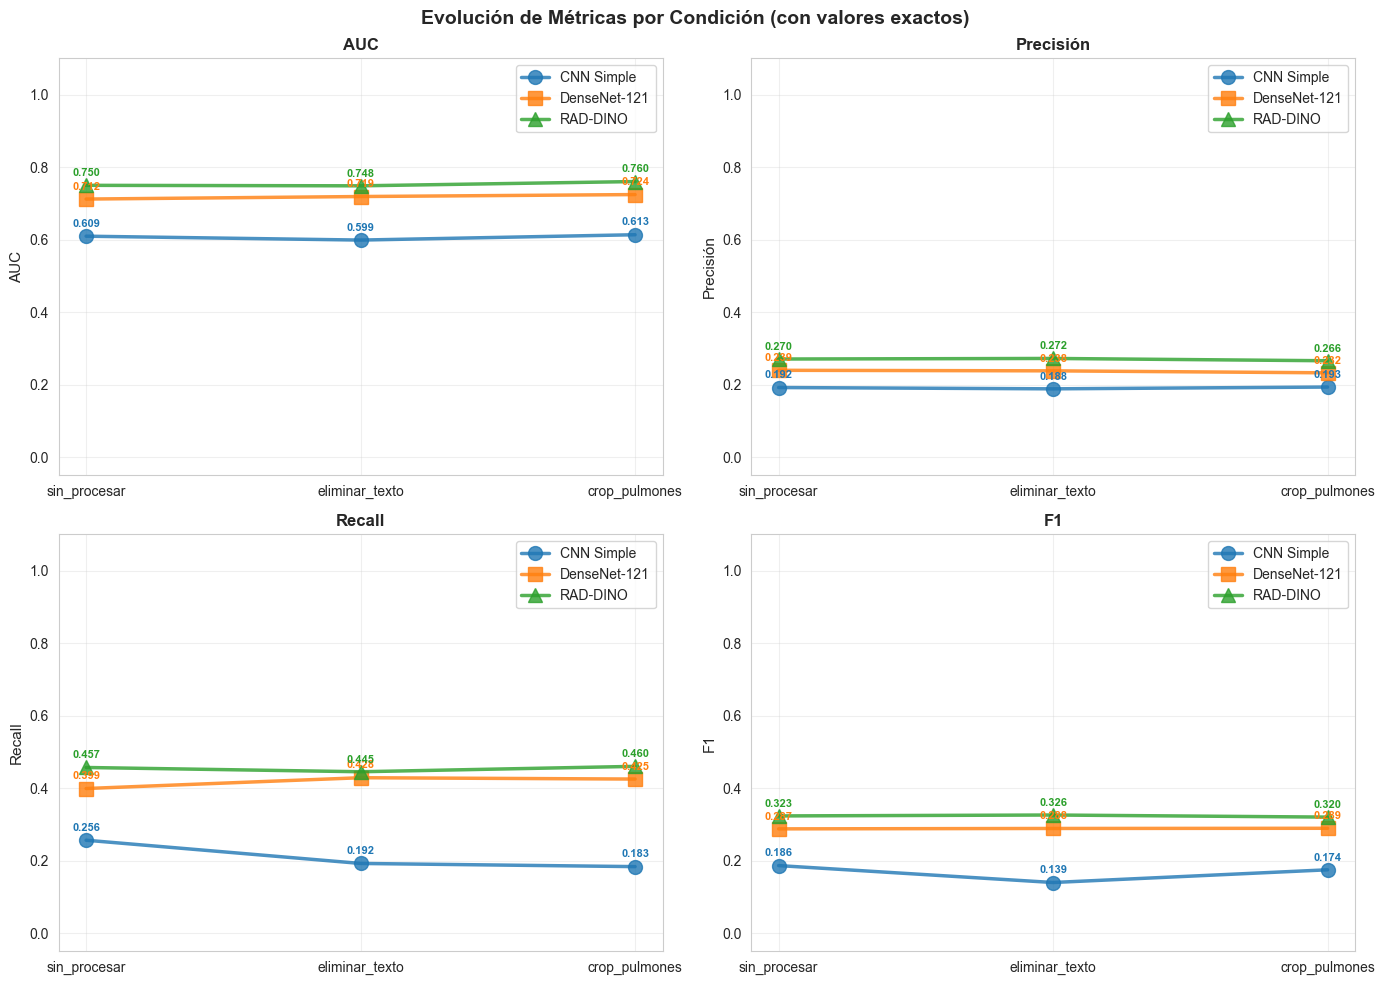

In [15]:
# MEJOR: LÍNEAS + VALORES NUMÉRICOS
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
condiciones = ['sin_procesar', 'eliminar_texto', 'crop_pulmones']
colores = {'CNN Simple': '#1f77b4', 'DenseNet-121': '#ff7f0e', 'RAD-DINO': '#2ca02c'}
markers = {'CNN Simple': 'o', 'DenseNet-121': 's', 'RAD-DINO': '^'}

for idx, metrica in enumerate(['AUC', 'Precisión', 'Recall', 'F1']):
    for modelo in df['Modelo'].unique():
        datos_modelo = df[df['Modelo'] == modelo]
        valores = [datos_modelo[datos_modelo['Condición'] == c][metrica].mean() for c in condiciones]
        
        # Línea
        axes[idx].plot(condiciones, valores, marker=markers[modelo], linewidth=2.5, markersize=10,
                      label=modelo, color=colores[modelo], alpha=0.8)
        
        # Valores numéricos sobre puntos
        for x, y in enumerate(valores):
            axes[idx].text(x, y + 0.02, f'{y:.3f}', ha='center', va='bottom', 
                          fontsize=8, fontweight='bold', color=colores[modelo])
    
    axes[idx].set_title(f'{metrica}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(metrica, fontsize=11)
    axes[idx].set_ylim(-0.05, 1.1)
    axes[idx].legend(fontsize=10, loc='best')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Evolución de Métricas por Condición (con valores exactos)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

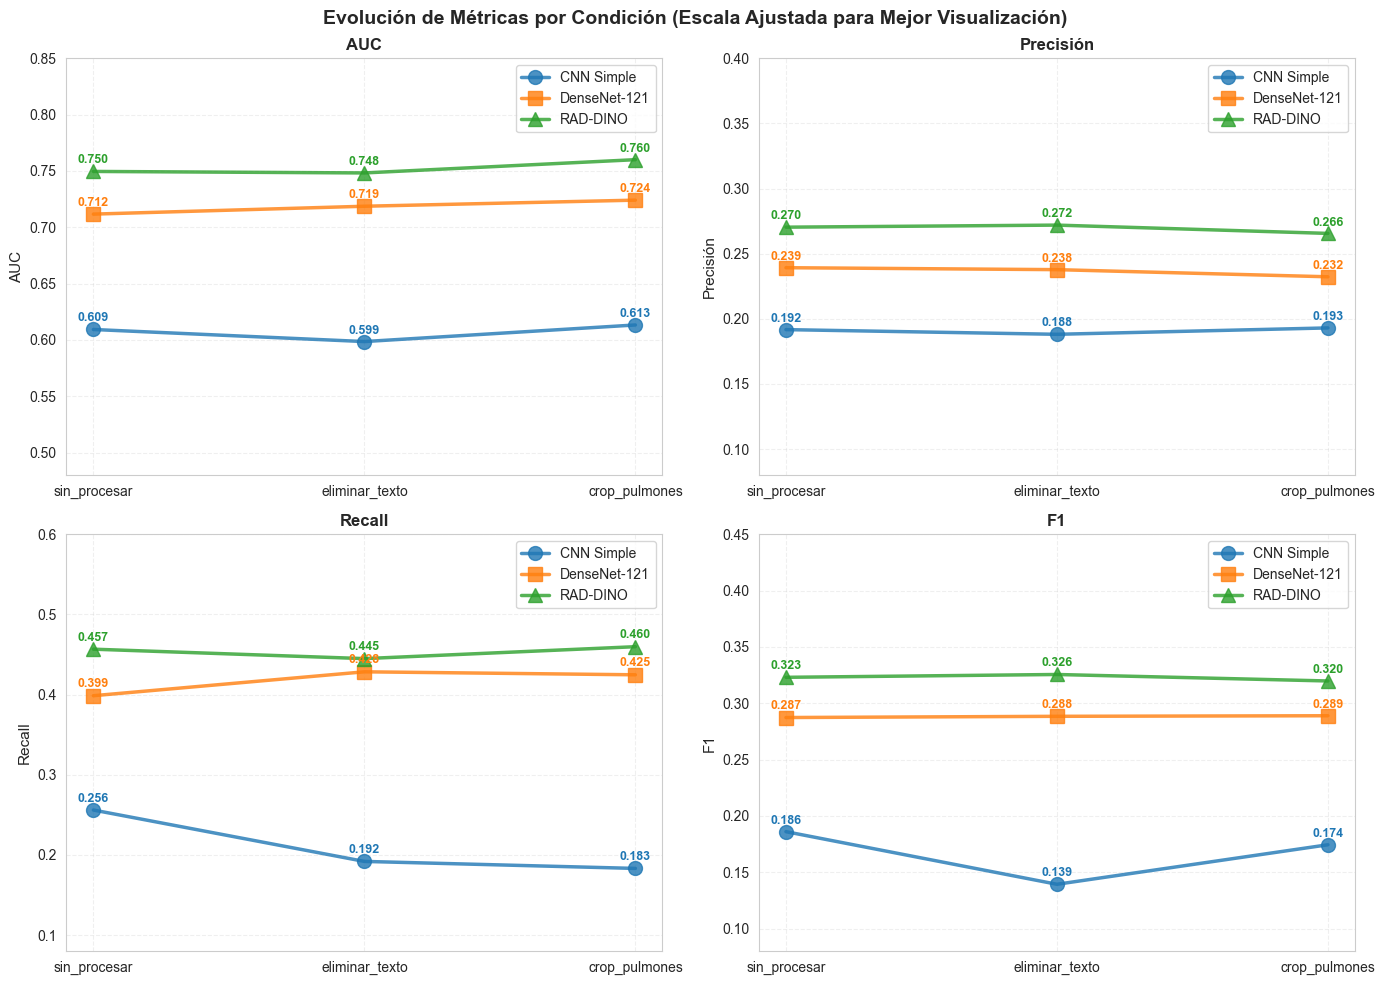

In [16]:
# MEJORA: LÍNEAS CON ESCALA AJUSTADA POR MÉTRICA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
condiciones = ['sin_procesar', 'eliminar_texto', 'crop_pulmones']
colores = {'CNN Simple': '#1f77b4', 'DenseNet-121': '#ff7f0e', 'RAD-DINO': '#2ca02c'}
markers = {'CNN Simple': 'o', 'DenseNet-121': 's', 'RAD-DINO': '^'}

# Ajustar escala por métrica para mejor visualización
escalas = {
    'AUC': (0.50, 0.80),          # Zoom desde 0.5 a 0.8
    'Precisión': (0.10, 0.35),    # Zoom desde 0.1 a 0.35
    'Recall': (0.10, 0.55),       # Zoom desde 0.1 a 0.55
    'F1': (0.10, 0.40)            # Zoom desde 0.1 a 0.4
}

for idx, metrica in enumerate(['AUC', 'Precisión', 'Recall', 'F1']):
    for modelo in df['Modelo'].unique():
        datos_modelo = df[df['Modelo'] == modelo]
        valores = [datos_modelo[datos_modelo['Condición'] == c][metrica].mean() for c in condiciones]
        
        # Línea
        axes[idx].plot(condiciones, valores, marker=markers[modelo], linewidth=2.5, markersize=10,
                      label=modelo, color=colores[modelo], alpha=0.8)
        
        # Valores numéricos sobre puntos
        for x, y in enumerate(valores):
            axes[idx].text(x, y + (escalas[metrica][1] - escalas[metrica][0]) * 0.015, 
                          f'{y:.3f}', ha='center', va='bottom', 
                          fontsize=9, fontweight='bold', color=colores[modelo])
    
    # Aplicar escala personalizada
    ymin, ymax = escalas[metrica]
    axes[idx].set_ylim(ymin - 0.02, ymax + 0.05)
    
    axes[idx].set_title(f'{metrica}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(metrica, fontsize=11)
    axes[idx].legend(fontsize=10, loc='best')
    axes[idx].grid(True, alpha=0.3, linestyle='--')
    axes[idx].set_axisbelow(True)

plt.suptitle('Evolución de Métricas por Condición (Escala Ajustada para Mejor Visualización)', 
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

ANÁLISIS DETALLADO POR MODELO - PROYECTO TÓRAX


████████████████████████████████████████████████████████████████████████████████████████████████████
█                                 CNN SIMPLE - ANÁLISIS DETALLADO                                  █
████████████████████████████████████████████████████████████████████████████████████████████████████

[INFO] Total de labels: 13
[INFO] Condiciones analizadas: 3
[INFO] Total de registros: 39

--- RESUMEN DE MÉTRICAS POR CONDICIÓN ---
                   AUC  Precisión  Recall      F1
Condición                                        
crop_pulmones   0.6235     0.1893  0.2328  0.1903
eliminar_texto  0.5986     0.1881  0.1919  0.1394
sin_procesar    0.6093     0.1917  0.2560  0.1861


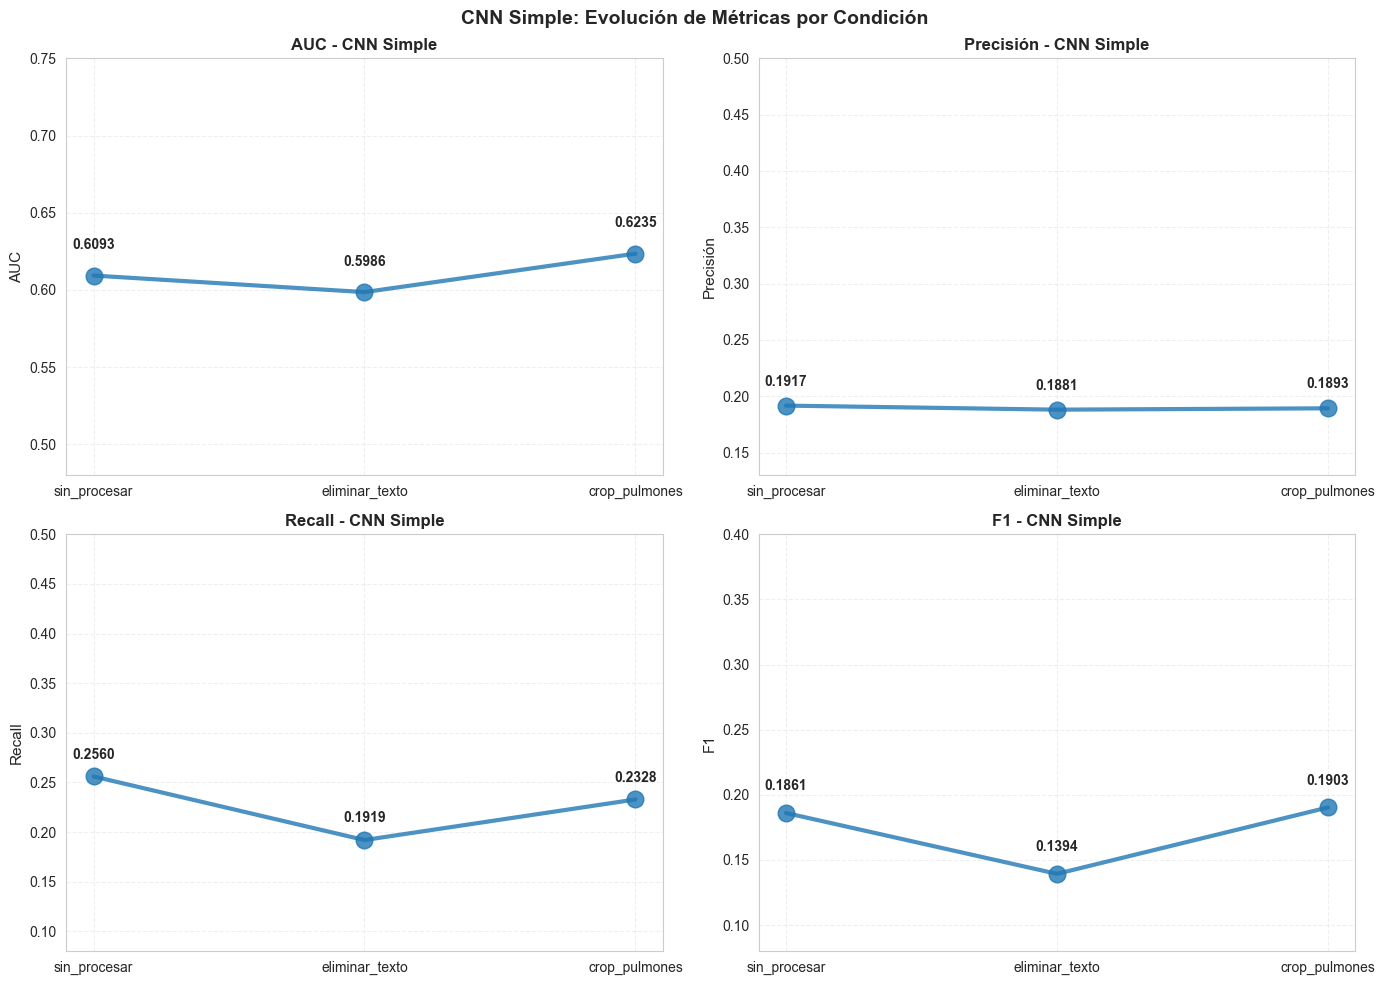

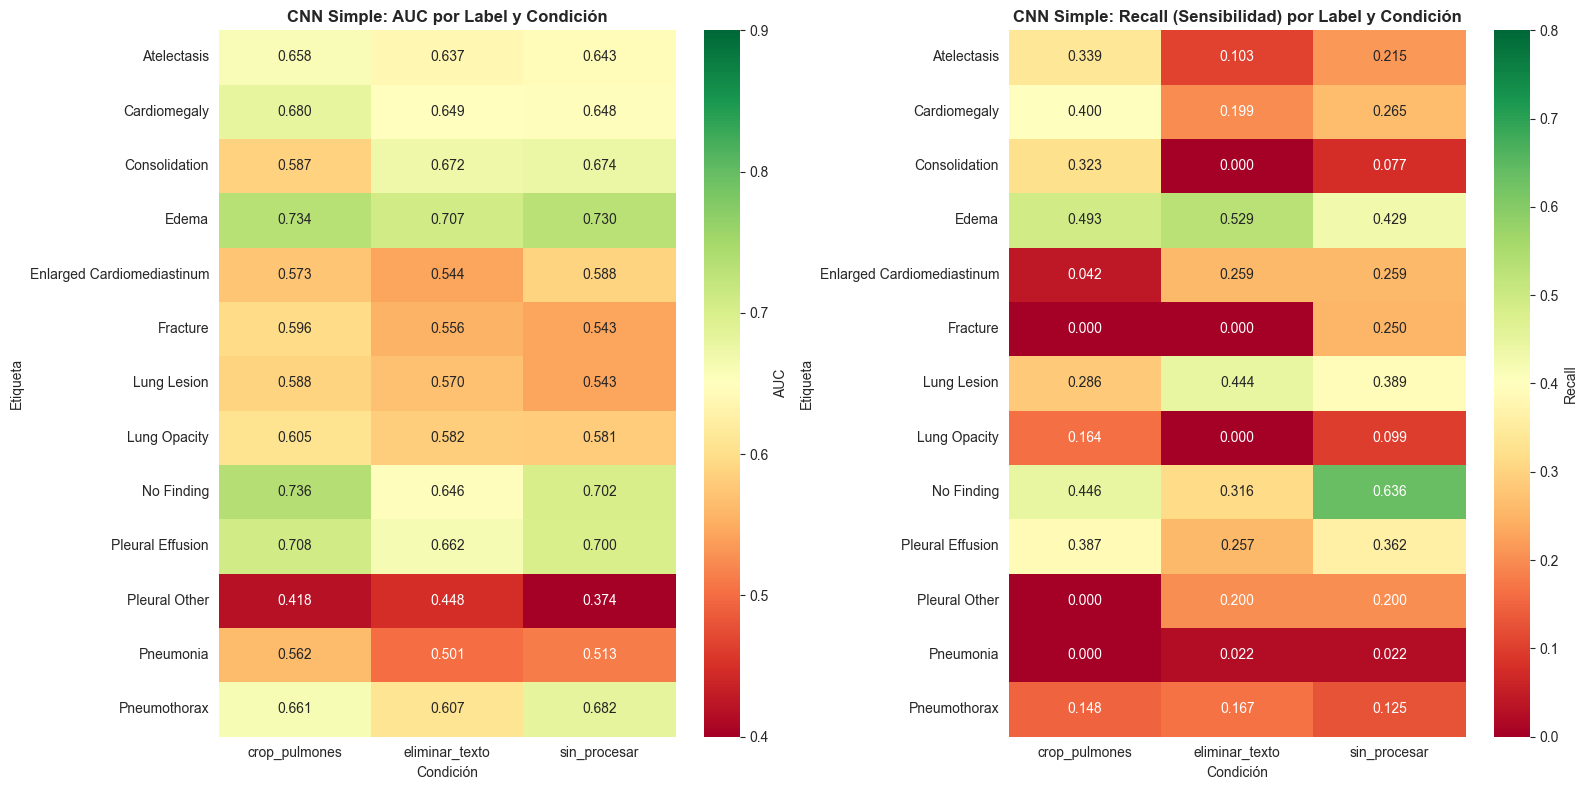


--- RESULTADOS DETALLADOS POR LABEL Y CONDICIÓN ---

Atelectasis:
  sin_procesar     → AUC: 0.6430 | Prec: 0.3165 | Recall: 0.2155 | F1: 0.2564
  eliminar_texto   → AUC: 0.6368 | Prec: 0.3077 | Recall: 0.1034 | F1: 0.1548
  crop_pulmones    → AUC: 0.6579 | Prec: 0.3628 | Recall: 0.3388 | F1: 0.3504

Cardiomegaly:
  sin_procesar     → AUC: 0.6480 | Prec: 0.3871 | Recall: 0.2647 | F1: 0.3144
  eliminar_texto   → AUC: 0.6486 | Prec: 0.5192 | Recall: 0.1985 | F1: 0.2872
  crop_pulmones    → AUC: 0.6804 | Prec: 0.3212 | Recall: 0.4000 | F1: 0.3563

Consolidation:
  sin_procesar     → AUC: 0.6741 | Prec: 0.0645 | Recall: 0.0769 | F1: 0.0702
  eliminar_texto   → AUC: 0.6723 | Prec: 0.0000 | Recall: 0.0000 | F1: 0.0000
  crop_pulmones    → AUC: 0.5870 | Prec: 0.0971 | Recall: 0.3226 | F1: 0.1493

Edema:
  sin_procesar     → AUC: 0.7303 | Prec: 0.2830 | Recall: 0.4286 | F1: 0.3409
  eliminar_texto   → AUC: 0.7074 | Prec: 0.2176 | Recall: 0.5286 | F1: 0.3083
  crop_pulmones    → AUC: 0.7336 | P

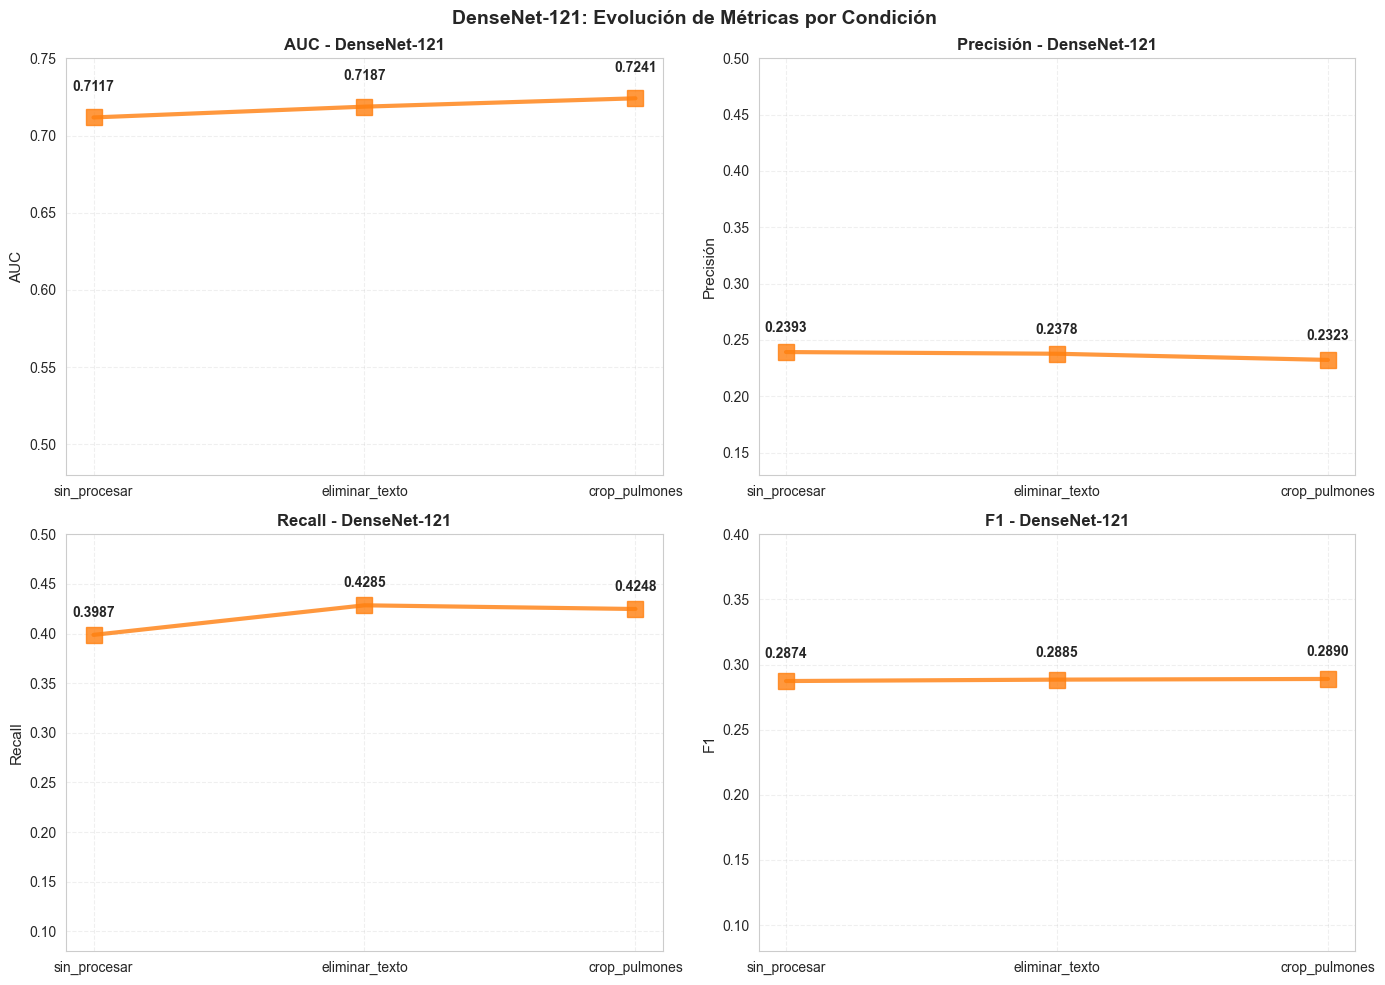

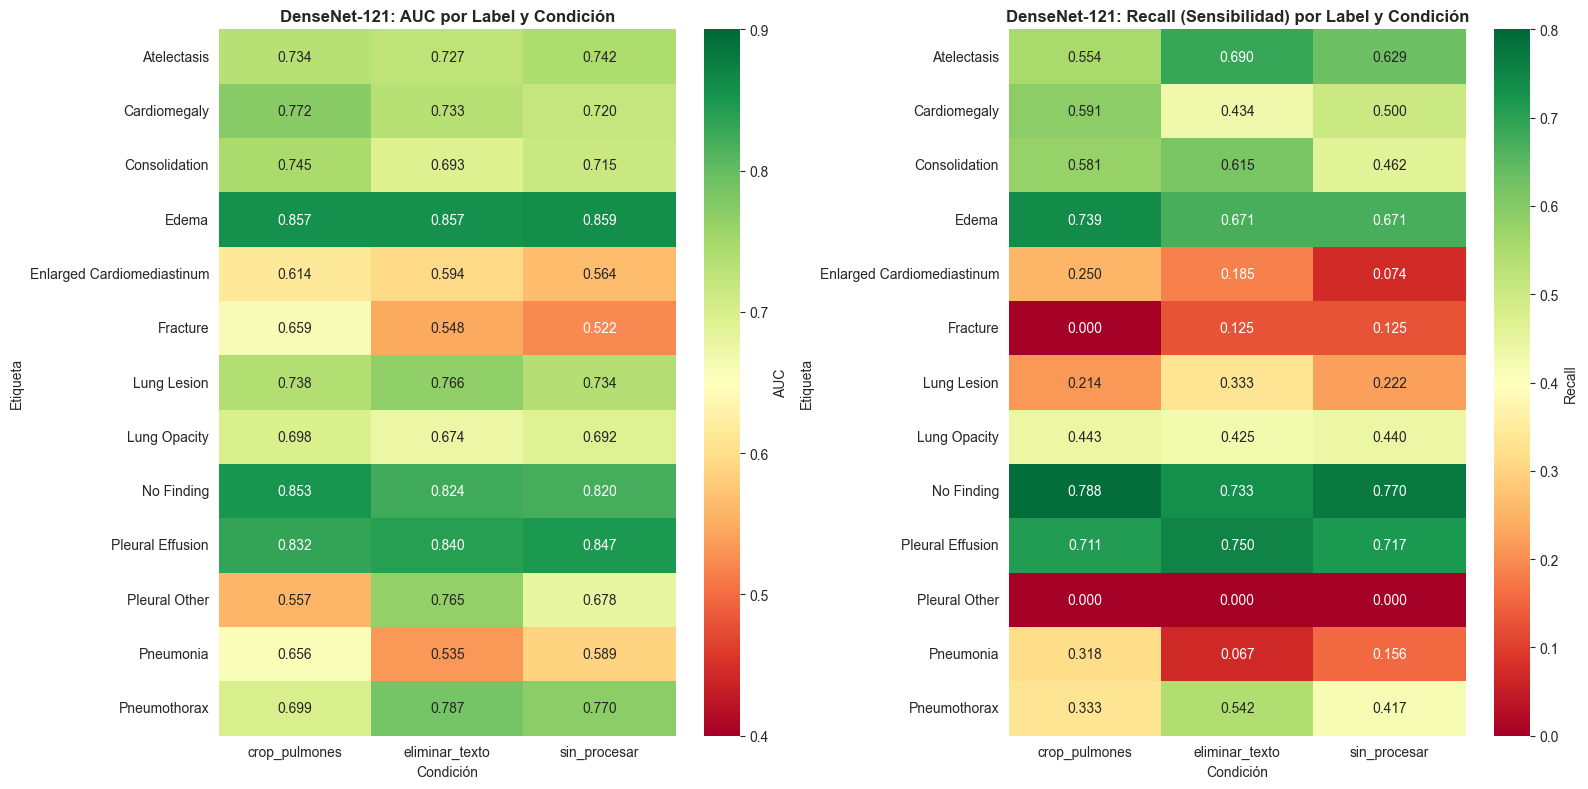


--- RESULTADOS DETALLADOS POR LABEL Y CONDICIÓN ---

Atelectasis:
  sin_procesar     → AUC: 0.7419 | Prec: 0.3527 | Recall: 0.6293 | F1: 0.4520
  eliminar_texto   → AUC: 0.7269 | Prec: 0.3390 | Recall: 0.6897 | F1: 0.4545
  crop_pulmones    → AUC: 0.7338 | Prec: 0.3472 | Recall: 0.5537 | F1: 0.4268

Cardiomegaly:
  sin_procesar     → AUC: 0.7198 | Prec: 0.3736 | Recall: 0.5000 | F1: 0.4277
  eliminar_texto   → AUC: 0.7331 | Prec: 0.3782 | Recall: 0.4338 | F1: 0.4041
  crop_pulmones    → AUC: 0.7722 | Prec: 0.3457 | Recall: 0.5909 | F1: 0.4362

Consolidation:
  sin_procesar     → AUC: 0.7148 | Prec: 0.1008 | Recall: 0.4615 | F1: 0.1655
  eliminar_texto   → AUC: 0.6932 | Prec: 0.1060 | Recall: 0.6154 | F1: 0.1808
  crop_pulmones    → AUC: 0.7452 | Prec: 0.1104 | Recall: 0.5806 | F1: 0.1856

Edema:
  sin_procesar     → AUC: 0.8591 | Prec: 0.3431 | Recall: 0.6714 | F1: 0.4541
  eliminar_texto   → AUC: 0.8570 | Prec: 0.3456 | Recall: 0.6714 | F1: 0.4563
  crop_pulmones    → AUC: 0.8568 | P

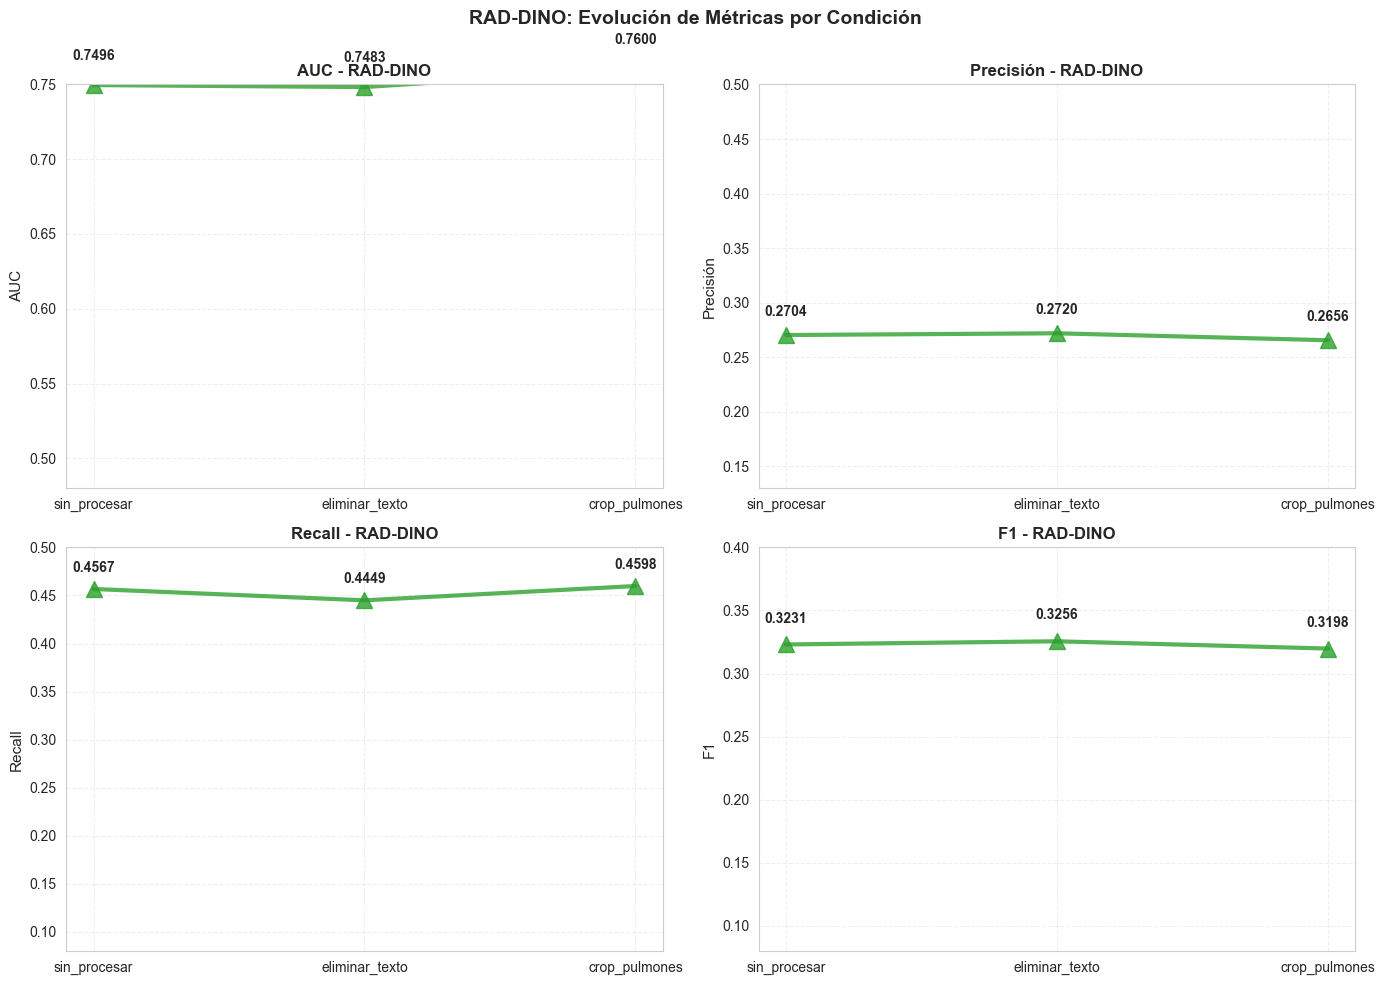

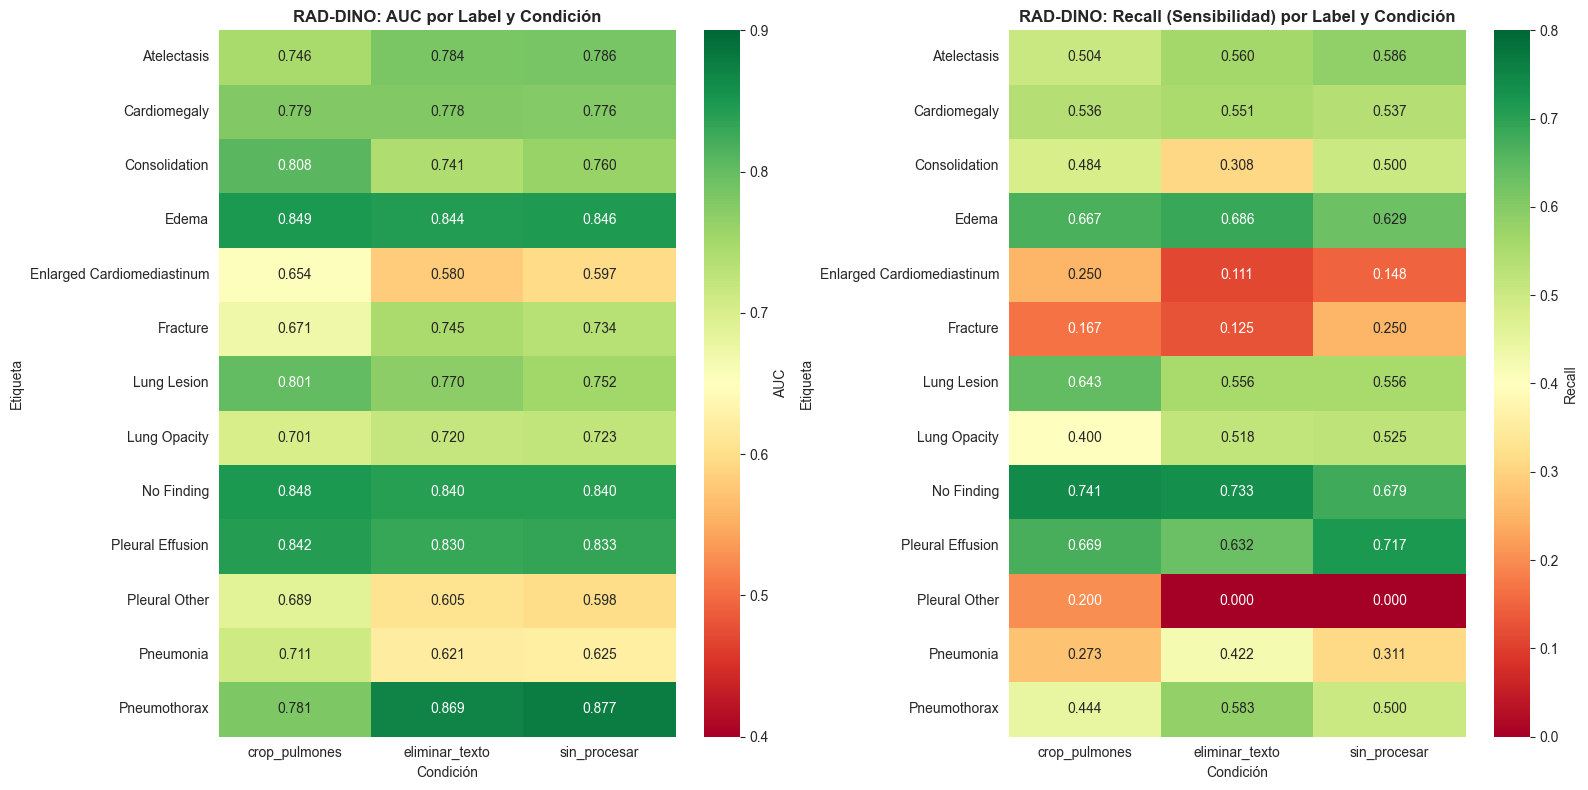


--- RESULTADOS DETALLADOS POR LABEL Y CONDICIÓN ---

Atelectasis:
  sin_procesar     → AUC: 0.7857 | Prec: 0.4626 | Recall: 0.5862 | F1: 0.5171
  eliminar_texto   → AUC: 0.7841 | Prec: 0.4362 | Recall: 0.5603 | F1: 0.4906
  crop_pulmones    → AUC: 0.7463 | Prec: 0.3935 | Recall: 0.5041 | F1: 0.4420

Cardiomegaly:
  sin_procesar     → AUC: 0.7758 | Prec: 0.4591 | Recall: 0.5368 | F1: 0.4949
  eliminar_texto   → AUC: 0.7778 | Prec: 0.4491 | Recall: 0.5515 | F1: 0.4950
  crop_pulmones    → AUC: 0.7787 | Prec: 0.3960 | Recall: 0.5364 | F1: 0.4556

Consolidation:
  sin_procesar     → AUC: 0.7599 | Prec: 0.1140 | Recall: 0.5000 | F1: 0.1857
  eliminar_texto   → AUC: 0.7413 | Prec: 0.1404 | Recall: 0.3077 | F1: 0.1928
  crop_pulmones    → AUC: 0.8078 | Prec: 0.1339 | Recall: 0.4839 | F1: 0.2098

Edema:
  sin_procesar     → AUC: 0.8464 | Prec: 0.3212 | Recall: 0.6286 | F1: 0.4251
  eliminar_texto   → AUC: 0.8438 | Prec: 0.3097 | Recall: 0.6857 | F1: 0.4267
  crop_pulmones    → AUC: 0.8491 | P

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# df = pd.read_excel(...)

print("="*100)
print("ANÁLISIS DETALLADO POR MODELO - PROYECTO TÓRAX")
print("="*100)

# ============================================================
# ANÁLISIS MODELO 1: CNN SIMPLE
# ============================================================
print("\n\n" + "█"*100)
print("█ " + "CNN SIMPLE - ANÁLISIS DETALLADO".center(96) + " █")
print("█"*100)

modelo_actual = 'CNN Simple'
datos_cnn = df[df['Modelo'] == modelo_actual]

print(f"\n[INFO] Total de labels: {datos_cnn['Etiqueta'].nunique()}")
print(f"[INFO] Condiciones analizadas: {datos_cnn['Condición'].nunique()}")
print(f"[INFO] Total de registros: {len(datos_cnn)}")

# 1. RESUMEN DE MÉTRICAS
print("\n--- RESUMEN DE MÉTRICAS POR CONDICIÓN ---")
resumen_cnn = datos_cnn.groupby('Condición')[['AUC', 'Precisión', 'Recall', 'F1']].mean()
print(resumen_cnn.round(4))

# 2. GRÁFICO 1: LÍNEAS CON ESCALA AJUSTADA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
condiciones = ['sin_procesar', 'eliminar_texto', 'crop_pulmones']
escalas = {
    'AUC': (0.50, 0.70),
    'Precisión': (0.15, 0.45),
    'Recall': (0.10, 0.45),
    'F1': (0.10, 0.35)
}

for idx, metrica in enumerate(['AUC', 'Precisión', 'Recall', 'F1']):
    valores = [datos_cnn[datos_cnn['Condición'] == c][metrica].mean() for c in condiciones]
    
    axes[idx].plot(condiciones, valores, marker='o', linewidth=3, markersize=12,
                  color='#1f77b4', alpha=0.8)
    
    # Valores sobre puntos
    for x, y in enumerate(valores):
        axes[idx].text(x, y + 0.015, f'{y:.4f}', ha='center', va='bottom',
                      fontsize=10, fontweight='bold')
    
    ymin, ymax = escalas[metrica]
    axes[idx].set_ylim(ymin - 0.02, ymax + 0.05)
    axes[idx].set_title(f'{metrica} - CNN Simple', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(metrica, fontsize=11)
    axes[idx].grid(True, alpha=0.3, linestyle='--')
    axes[idx].set_axisbelow(True)

plt.suptitle('CNN Simple: Evolución de Métricas por Condición', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. HEATMAP: TODAS LAS MÉTRICAS
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Heatmap AUC
heatmap_auc = datos_cnn.pivot_table(index='Etiqueta', columns='Condición', values='AUC')
sns.heatmap(heatmap_auc, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.4, vmax=0.9,
           ax=axes[0], cbar_kws={'label': 'AUC'})
axes[0].set_title('CNN Simple: AUC por Label y Condición', fontsize=12, fontweight='bold')

# Heatmap Recall (crítico)
heatmap_recall = datos_cnn.pivot_table(index='Etiqueta', columns='Condición', values='Recall')
sns.heatmap(heatmap_recall, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=0.8,
           ax=axes[1], cbar_kws={'label': 'Recall'})
axes[1].set_title('CNN Simple: Recall (Sensibilidad) por Label y Condición', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. TABLA DETALLADA
print("\n--- RESULTADOS DETALLADOS POR LABEL Y CONDICIÓN ---")
for etiqueta in sorted(datos_cnn['Etiqueta'].unique()):
    print(f"\n{etiqueta}:")
    etiqueta_data = datos_cnn[datos_cnn['Etiqueta'] == etiqueta]
    for cond in condiciones:
        fila = etiqueta_data[etiqueta_data['Condición'] == cond]
        if len(fila) > 0:
            print(f"  {cond:16} → AUC: {fila['AUC'].values[0]:.4f} | Prec: {fila['Precisión'].values[0]:.4f} | Recall: {fila['Recall'].values[0]:.4f} | F1: {fila['F1'].values[0]:.4f}")

# 5. DELTAS ΔAUC
print("\n--- IMPACTO DEL PREPROCESAMIENTO (ΔAUC vs baseline) ---")
for etiqueta in sorted(datos_cnn['Etiqueta'].unique()):
    etiqueta_data = datos_cnn[datos_cnn['Etiqueta'] == etiqueta]
    baseline = etiqueta_data[etiqueta_data['Condición'] == 'sin_procesar']['AUC'].values[0]
    
    delta_et = etiqueta_data[etiqueta_data['Condición'] == 'eliminar_texto']['AUC'].values[0] - baseline
    delta_crop = etiqueta_data[etiqueta_data['Condición'] == 'crop_pulmones']['AUC'].values[0] - baseline
    
    print(f"  {etiqueta:25} Δ eliminar_texto: {delta_et:+.4f} | Δ crop: {delta_crop:+.4f}")

# ============================================================
# ANÁLISIS MODELO 2: DENSENET-121
# ============================================================
print("\n\n" + "█"*100)
print("█ " + "DENSENET-121 - ANÁLISIS DETALLADO".center(96) + " █")
print("█"*100)

modelo_actual = 'DenseNet-121'
datos_dn = df[df['Modelo'] == modelo_actual]

print(f"\n[INFO] Total de labels: {datos_dn['Etiqueta'].nunique()}")
print(f"[INFO] Condiciones analizadas: {datos_dn['Condición'].nunique()}")
print(f"[INFO] Total de registros: {len(datos_dn)}")

# 1. RESUMEN DE MÉTRICAS
print("\n--- RESUMEN DE MÉTRICAS POR CONDICIÓN ---")
resumen_dn = datos_dn.groupby('Condición')[['AUC', 'Precisión', 'Recall', 'F1']].mean()
print(resumen_dn.round(4))

# 2. GRÁFICO
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, metrica in enumerate(['AUC', 'Precisión', 'Recall', 'F1']):
    valores = [datos_dn[datos_dn['Condición'] == c][metrica].mean() for c in condiciones]
    
    axes[idx].plot(condiciones, valores, marker='s', linewidth=3, markersize=12,
                  color='#ff7f0e', alpha=0.8)
    
    for x, y in enumerate(valores):
        axes[idx].text(x, y + 0.015, f'{y:.4f}', ha='center', va='bottom',
                      fontsize=10, fontweight='bold')
    
    ymin, ymax = escalas[metrica]
    axes[idx].set_ylim(ymin - 0.02, ymax + 0.05)
    axes[idx].set_title(f'{metrica} - DenseNet-121', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(metrica, fontsize=11)
    axes[idx].grid(True, alpha=0.3, linestyle='--')

plt.suptitle('DenseNet-121: Evolución de Métricas por Condición', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. HEATMAP
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

heatmap_auc = datos_dn.pivot_table(index='Etiqueta', columns='Condición', values='AUC')
sns.heatmap(heatmap_auc, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.4, vmax=0.9,
           ax=axes[0], cbar_kws={'label': 'AUC'})
axes[0].set_title('DenseNet-121: AUC por Label y Condición', fontsize=12, fontweight='bold')

heatmap_recall = datos_dn.pivot_table(index='Etiqueta', columns='Condición', values='Recall')
sns.heatmap(heatmap_recall, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=0.8,
           ax=axes[1], cbar_kws={'label': 'Recall'})
axes[1].set_title('DenseNet-121: Recall (Sensibilidad) por Label y Condición', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. TABLA DETALLADA
print("\n--- RESULTADOS DETALLADOS POR LABEL Y CONDICIÓN ---")
for etiqueta in sorted(datos_dn['Etiqueta'].unique()):
    print(f"\n{etiqueta}:")
    etiqueta_data = datos_dn[datos_dn['Etiqueta'] == etiqueta]
    for cond in condiciones:
        fila = etiqueta_data[etiqueta_data['Condición'] == cond]
        if len(fila) > 0:
            print(f"  {cond:16} → AUC: {fila['AUC'].values[0]:.4f} | Prec: {fila['Precisión'].values[0]:.4f} | Recall: {fila['Recall'].values[0]:.4f} | F1: {fila['F1'].values[0]:.4f}")

# 5. DELTAS
print("\n--- IMPACTO DEL PREPROCESAMIENTO (ΔAUC vs baseline) ---")
for etiqueta in sorted(datos_dn['Etiqueta'].unique()):
    etiqueta_data = datos_dn[datos_dn['Etiqueta'] == etiqueta]
    baseline = etiqueta_data[etiqueta_data['Condición'] == 'sin_procesar']['AUC'].values[0]
    
    delta_et = etiqueta_data[etiqueta_data['Condición'] == 'eliminar_texto']['AUC'].values[0] - baseline
    delta_crop = etiqueta_data[etiqueta_data['Condición'] == 'crop_pulmones']['AUC'].values[0] - baseline
    
    print(f"  {etiqueta:25} Δ eliminar_texto: {delta_et:+.4f} | Δ crop: {delta_crop:+.4f}")

# ============================================================
# ANÁLISIS MODELO 3: RAD-DINO
# ============================================================
print("\n\n" + "█"*100)
print("█ " + "RAD-DINO - ANÁLISIS DETALLADO".center(96) + " █")
print("█"*100)

modelo_actual = 'RAD-DINO'
datos_raddino = df[df['Modelo'] == modelo_actual]

print(f"\n[INFO] Total de labels: {datos_raddino['Etiqueta'].nunique()}")
print(f"[INFO] Condiciones analizadas: {datos_raddino['Condición'].nunique()}")
print(f"[INFO] Total de registros: {len(datos_raddino)}")

# 1. RESUMEN DE MÉTRICAS
print("\n--- RESUMEN DE MÉTRICAS POR CONDICIÓN ---")
resumen_raddino = datos_raddino.groupby('Condición')[['AUC', 'Precisión', 'Recall', 'F1']].mean()
print(resumen_raddino.round(4))

# 2. GRÁFICO
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, metrica in enumerate(['AUC', 'Precisión', 'Recall', 'F1']):
    valores = [datos_raddino[datos_raddino['Condición'] == c][metrica].mean() for c in condiciones]
    
    axes[idx].plot(condiciones, valores, marker='^', linewidth=3, markersize=12,
                  color='#2ca02c', alpha=0.8)
    
    for x, y in enumerate(valores):
        axes[idx].text(x, y + 0.015, f'{y:.4f}', ha='center', va='bottom',
                      fontsize=10, fontweight='bold')
    
    ymin, ymax = escalas[metrica]
    axes[idx].set_ylim(ymin - 0.02, ymax + 0.05)
    axes[idx].set_title(f'{metrica} - RAD-DINO', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(metrica, fontsize=11)
    axes[idx].grid(True, alpha=0.3, linestyle='--')

plt.suptitle('RAD-DINO: Evolución de Métricas por Condición', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. HEATMAP
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

heatmap_auc = datos_raddino.pivot_table(index='Etiqueta', columns='Condición', values='AUC')
sns.heatmap(heatmap_auc, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.4, vmax=0.9,
           ax=axes[0], cbar_kws={'label': 'AUC'})
axes[0].set_title('RAD-DINO: AUC por Label y Condición', fontsize=12, fontweight='bold')

heatmap_recall = datos_raddino.pivot_table(index='Etiqueta', columns='Condición', values='Recall')
sns.heatmap(heatmap_recall, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=0.8,
           ax=axes[1], cbar_kws={'label': 'Recall'})
axes[1].set_title('RAD-DINO: Recall (Sensibilidad) por Label y Condición', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. TABLA DETALLADA
print("\n--- RESULTADOS DETALLADOS POR LABEL Y CONDICIÓN ---")
for etiqueta in sorted(datos_raddino['Etiqueta'].unique()):
    print(f"\n{etiqueta}:")
    etiqueta_data = datos_raddino[datos_raddino['Etiqueta'] == etiqueta]
    for cond in condiciones:
        fila = etiqueta_data[etiqueta_data['Condición'] == cond]
        if len(fila) > 0:
            print(f"  {cond:16} → AUC: {fila['AUC'].values[0]:.4f} | Prec: {fila['Precisión'].values[0]:.4f} | Recall: {fila['Recall'].values[0]:.4f} | F1: {fila['F1'].values[0]:.4f}")

# 5. DELTAS
print("\n--- IMPACTO DEL PREPROCESAMIENTO (ΔAUC vs baseline) ---")
for etiqueta in sorted(datos_raddino['Etiqueta'].unique()):
    etiqueta_data = datos_raddino[datos_raddino['Etiqueta'] == etiqueta]
    baseline = etiqueta_data[etiqueta_data['Condición'] == 'sin_procesar']['AUC'].values[0]
    
    delta_et = etiqueta_data[etiqueta_data['Condición'] == 'eliminar_texto']['AUC'].values[0] - baseline
    delta_crop = etiqueta_data[etiqueta_data['Condición'] == 'crop_pulmones']['AUC'].values[0] - baseline
    
    print(f"  {etiqueta:25} Δ eliminar_texto: {delta_et:+.4f} | Δ crop: {delta_crop:+.4f}")

print("\n" + "="*100)
print("✅ ANÁLISIS MODELO POR MODELO COMPLETADO")
print("="*100)